In [1]:
import torch
import torchvision

#https://github.com/JohannesTheo/multi_object_datasets_torch
# @misc{multiobjectdatasets19,
#   title={Multi-Object Datasets},
#   author={Kabra, Rishabh and Burgess, Chris and Matthey, Loic and
#           Kaufman, Raphael Lopez and Greff, Klaus and Reynolds, Malcolm and
#           Lerchner, Alexander},
#   howpublished={https://github.com/JohannesTheo/multi_object_datasets_torch},
#   year={2019}
# }
from multi_object_datasets_torch import MultiDSprites ,ClevrWithMasks,Tetrominoes


import model as models
import tqdm
import argparse
import pickle
import matplotlib.pyplot as plt
import hungarian

In [2]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

parser = argparse.ArgumentParser()

model_dir='tetrominoes_backboned'
seed=0
batch_size=512
num_slots=4
num_iterations=3
hid_dim=64
learning_rate=10e-4
warmup_steps=2
decay_rate=0
num_workers=20
num_epochs=1000
decay_steps=num_epochs
reload=True

parser.add_argument('--model_dir', default=model_dir, type=str, help='where to save models' )
parser.add_argument('--seed', default=seed, type=int, help='random seed')
parser.add_argument('--batch_size', default=batch_size, type=int)
parser.add_argument('--num_slots', default=num_slots, type=int, help='# of slots')
parser.add_argument('--num_iterations', default=num_iterations, type=int, help='# iterations')
parser.add_argument('--hid_dim', default=hid_dim, type=int, help='hidden dimension size')
parser.add_argument('--learning_rate', default=learning_rate, type=float)
parser.add_argument('--warmup_steps', default=warmup_steps, type=int, help='# of warmup steps')
parser.add_argument('--decay_rate', default=decay_rate, type=float, help='decay rate')
parser.add_argument('--decay_steps', default=decay_steps, type=float, help='decay rate')
parser.add_argument('--num_workers', default=num_workers, type=int, help='# of workers for loading data')
parser.add_argument('--num_epochs', default=num_workers, type=int, help='# of epochs')

# opt = parser.parse_args()
# model_dir=opt.model_dir
# seed=opt.seed
# batch_size=opt.batch_size
# num_slots=opt.num_slots
# num_iterations=opt.num_iterations
# hid_dim=opt.hid_dim
# learning_rate=opt.learning_rate
# warmup_steps=opt.warmup_steps
# decay_rate=opt.decay_rate
# num_workers=opt.num_workers
# num_epochs=opt.num_epochs

_StoreAction(option_strings=['--num_epochs'], dest='num_epochs', nargs=None, const=None, default=20, type=<class 'int'>, choices=None, required=False, help='# of epochs', metavar=None)

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ConvertImageDtype(torch.float32),
])


In [4]:
train_set=Tetrominoes("data/Tetrominoes",download=True)
train_dataloader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True,num_workers=num_workers)

In [5]:
train_set[0]['mask'].shape

torch.Size([4, 1, 35, 35])

torch.Size([1, 3, 35, 35])


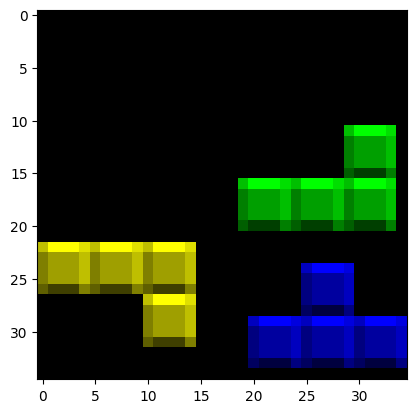

In [6]:
torch.manual_seed(seed)

visual=transform(train_set[0]['image'].unsqueeze(0)).to(device)
plt.imshow(visual.detach().to('cpu')[0,:,:,:].permute(1,2,0))
print(visual.shape)

In [7]:
resnet=torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
backbone=torch.nn.Sequential(*([*resnet.children()][:-4]))
for param in backbone.parameters():
    param.requires_grad=False
print(backbone.parameters())
model=models.AutoEncoder(CustomEncoder=backbone,feature_size=128,target_resolution=(35,35),base_resolution=(15,15),slot_iterations=num_iterations,stepsize=2,just_alpha=False,n_slots=num_slots).to(device)
loss_evolution=[]
if reload:
    model.load_state_dict(torch.load(model_dir+"/autosave.pt", weights_only=True), strict=False)
    with open(model_dir+"/stats.pkl",'rb') as r:
        loss_evolution=pickle.load(r)

<generator object Module.parameters at 0x7f6a602a6180>


In [8]:
def lr_sched(epoch):
    epoch+=1
    lr=learning_rate
    if epoch<warmup_steps:
        lr=lr/(epoch/warmup_steps)
    #lr*=decay_rate**(epoch/decay_steps)
    return lr

In [9]:
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
critres=torch.nn.MSELoss()
critmask=models.batch_matrix_hungarian_loss #torch.nn.MSELoss()
sched=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_sched)

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9445.8916015625, epoch:0/1000


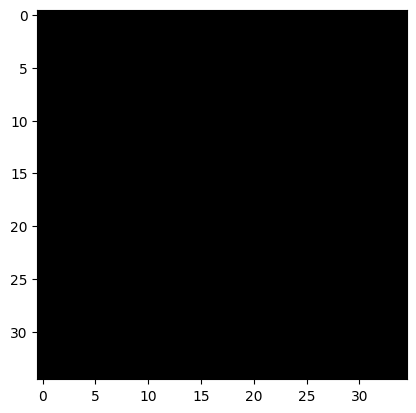

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9999.7236328125, epoch:1/1000


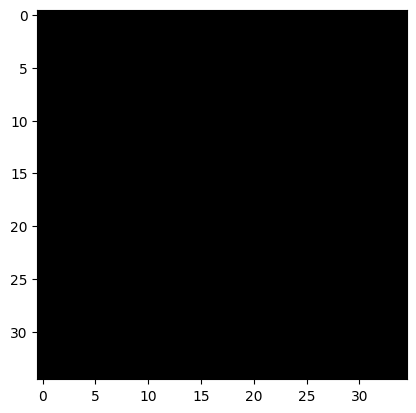

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9979.609375, epoch:2/1000


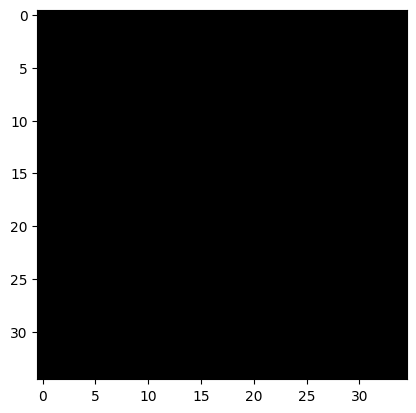

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10009.2939453125, epoch:3/1000


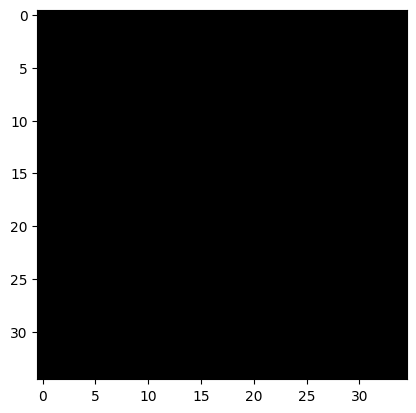

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9272.6416015625, epoch:4/1000


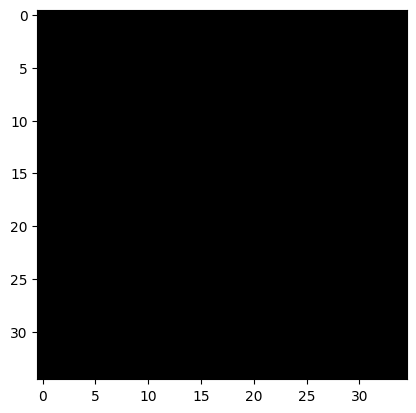

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10087.8525390625, epoch:5/1000


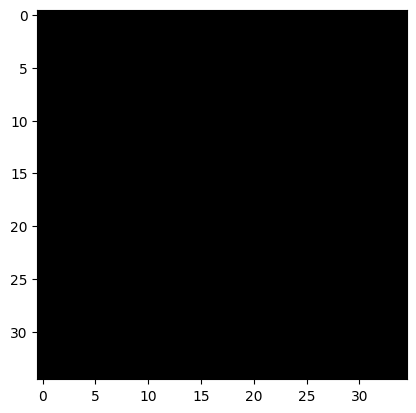

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10469.6630859375, epoch:6/1000


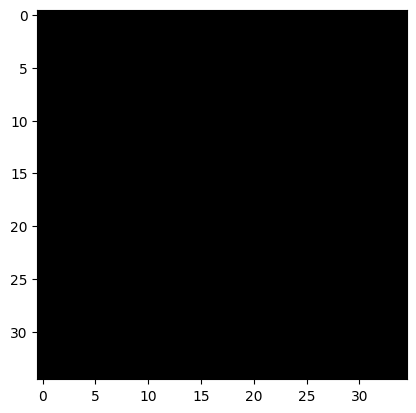

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9818.3896484375, epoch:7/1000


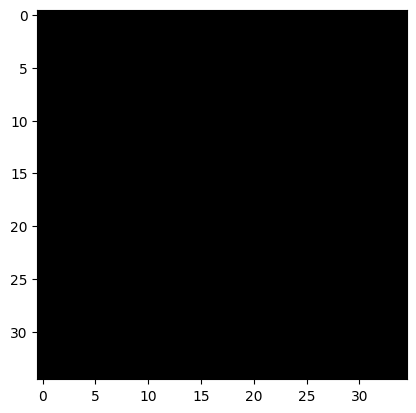

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9902.6201171875, epoch:8/1000


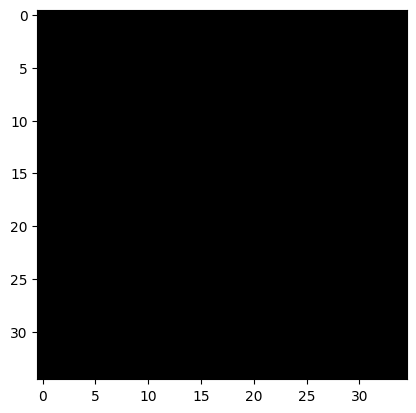

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9548.7626953125, epoch:9/1000


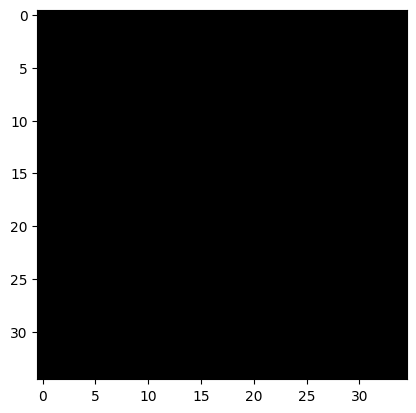

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9639.5302734375, epoch:10/1000


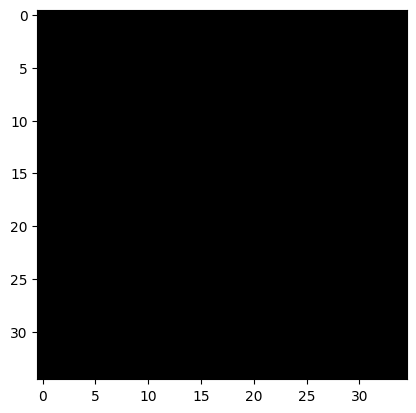

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9766.4638671875, epoch:11/1000


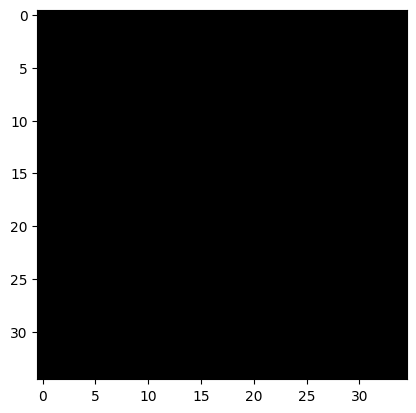

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9922.2919921875, epoch:12/1000


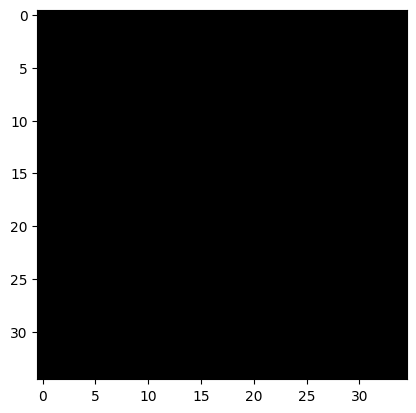

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9579.732421875, epoch:13/1000


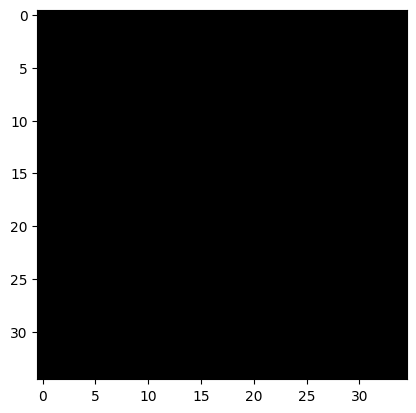

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9936.7666015625, epoch:14/1000


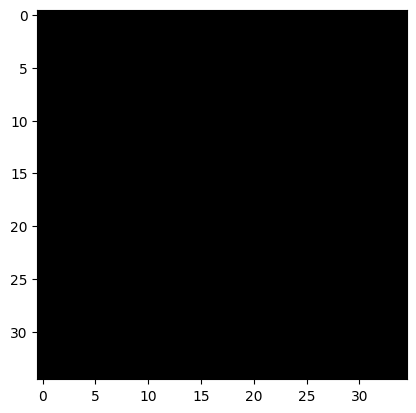

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 10301.0869140625, epoch:15/1000


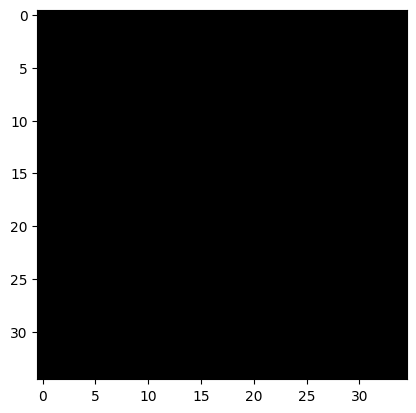

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9862.5439453125, epoch:16/1000


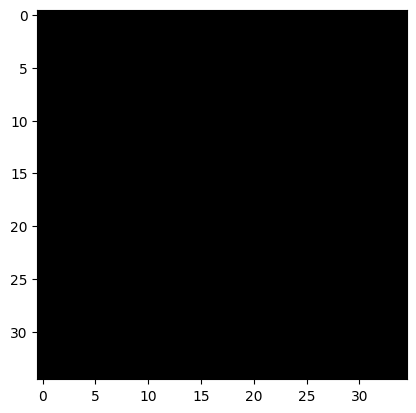

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9754.9501953125, epoch:17/1000


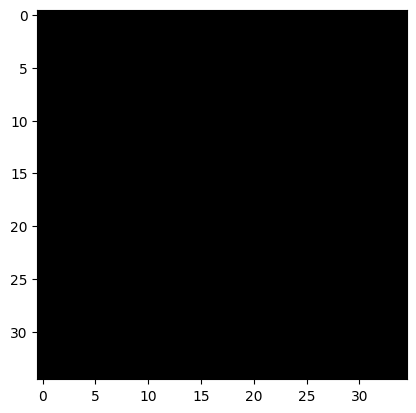

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9622.3193359375, epoch:18/1000


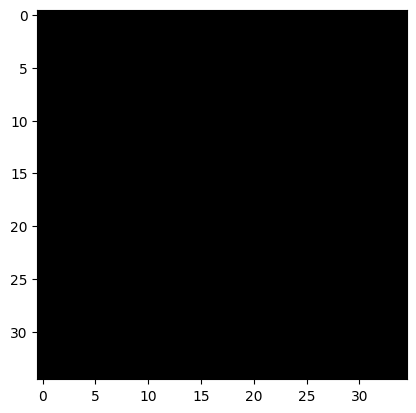

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9542.890625, epoch:19/1000


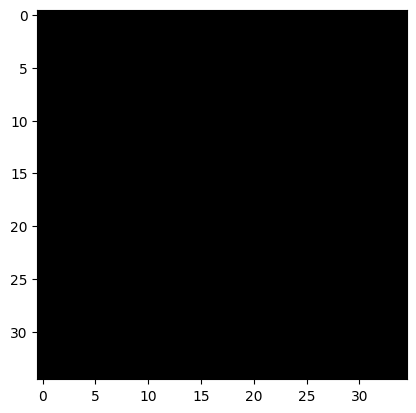

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9933.5439453125, epoch:20/1000


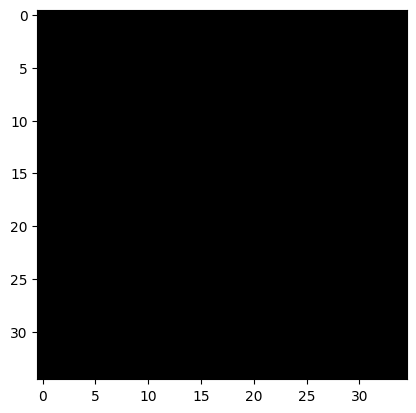

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9710.2802734375, epoch:21/1000


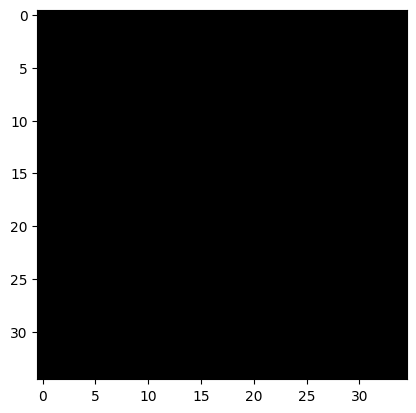

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10178.748046875, epoch:22/1000


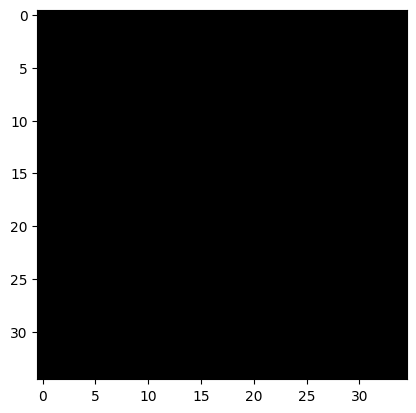

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9822.271484375, epoch:23/1000


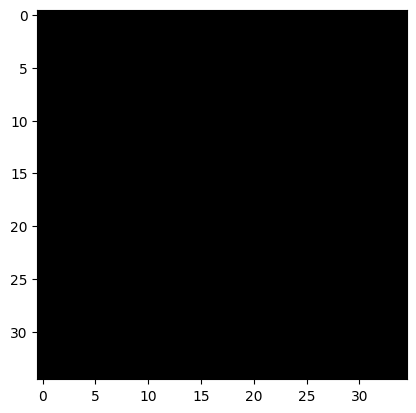

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10254.72265625, epoch:24/1000


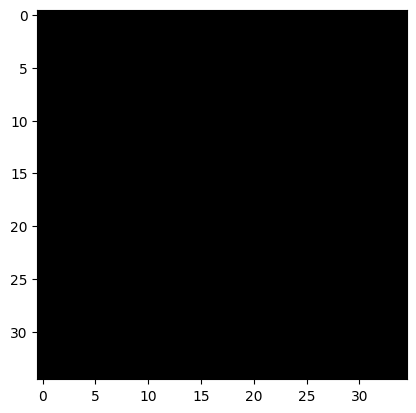

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 10131.525390625, epoch:25/1000


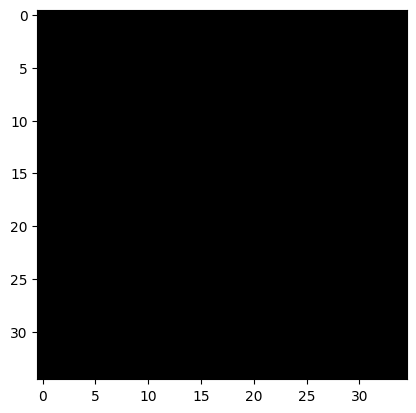

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10275.322265625, epoch:26/1000


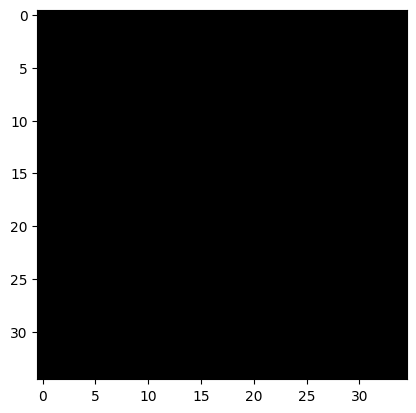

100%|██████████| 176/176 [01:02<00:00,  2.81it/s]

loss: 9553.9892578125, epoch:27/1000


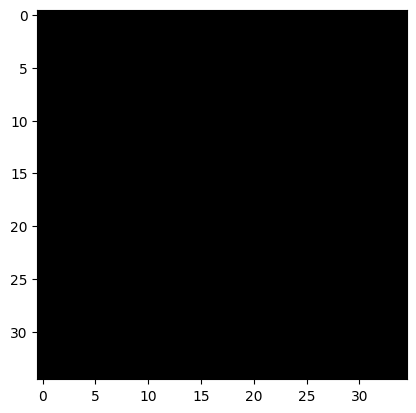

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10641.921875, epoch:28/1000


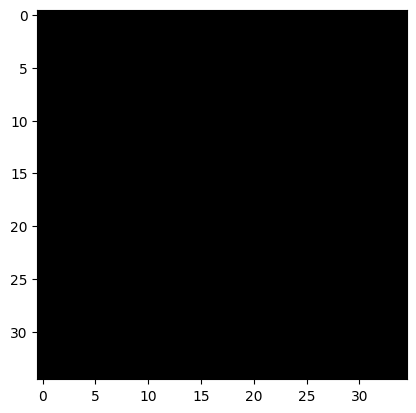

100%|██████████| 176/176 [01:02<00:00,  2.80it/s]


loss: 10059.6416015625, epoch:29/1000


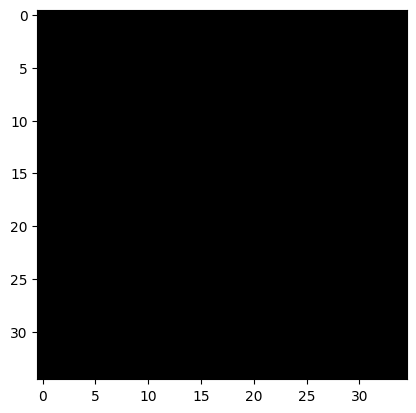

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10396.513671875, epoch:30/1000


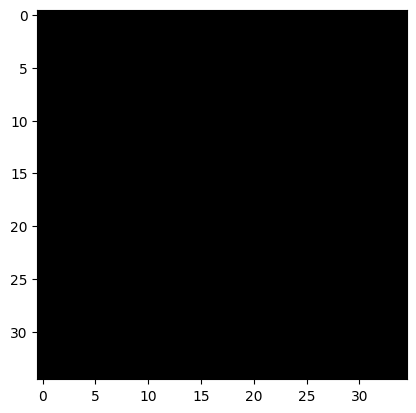

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9826.6552734375, epoch:31/1000


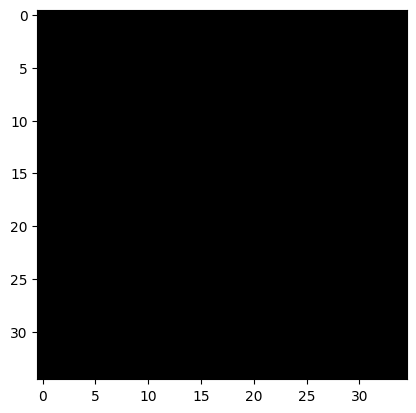

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10093.0419921875, epoch:32/1000


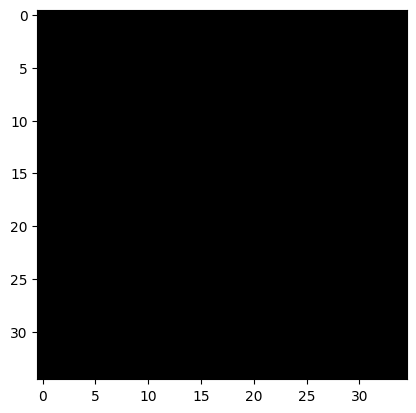

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9726.2294921875, epoch:33/1000


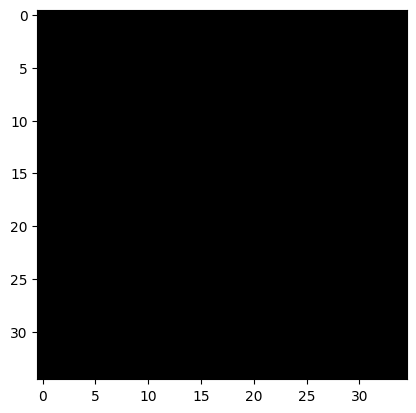

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9660.919921875, epoch:34/1000


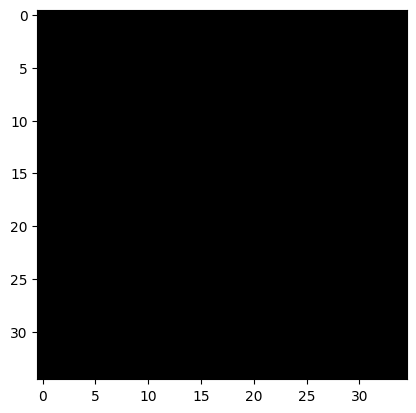

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 9770.8291015625, epoch:35/1000


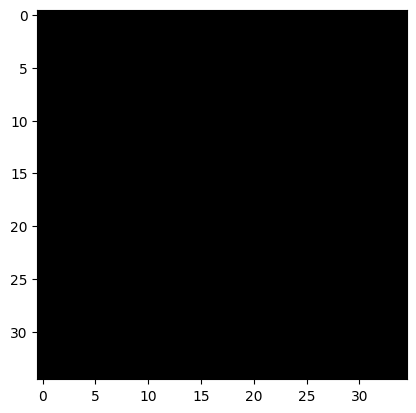

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10154.62890625, epoch:36/1000


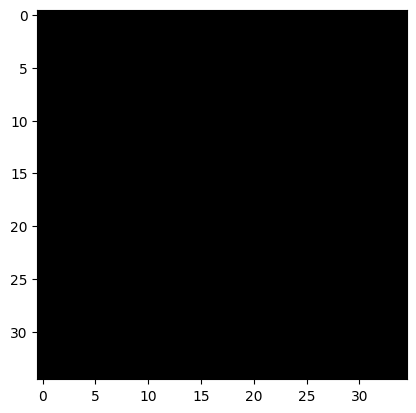

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9917.505859375, epoch:37/1000


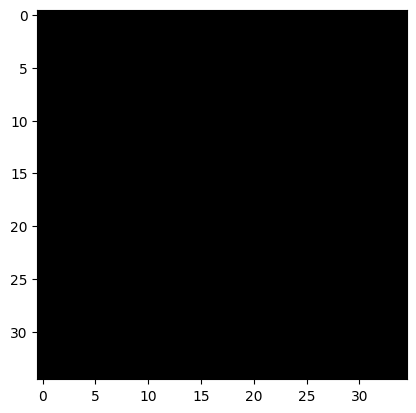

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10276.34375, epoch:38/1000


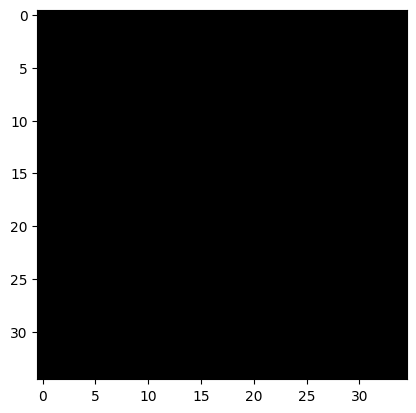

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10184.8828125, epoch:39/1000


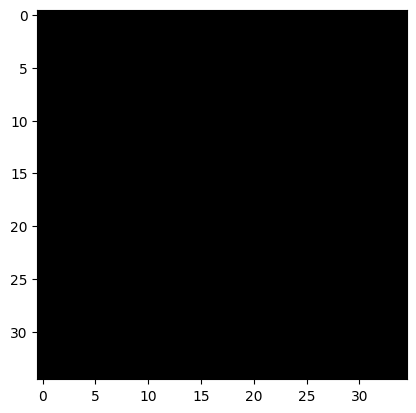

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10253.2353515625, epoch:40/1000


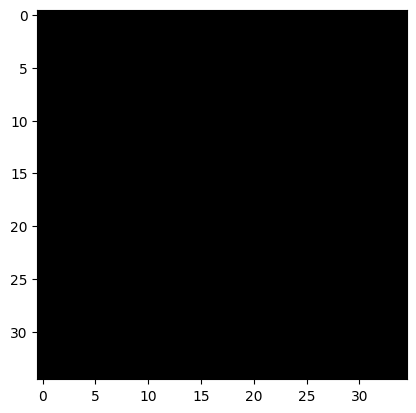

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10301.5009765625, epoch:41/1000


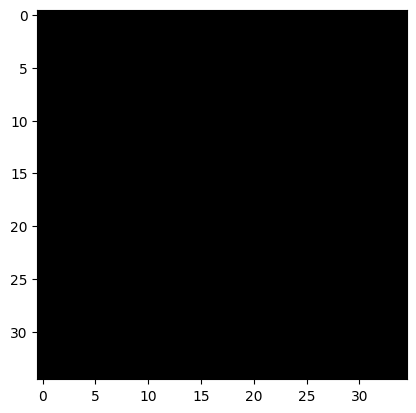

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10305.4375, epoch:42/1000


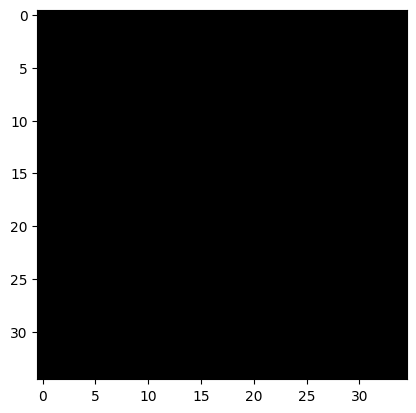

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9946.1728515625, epoch:43/1000


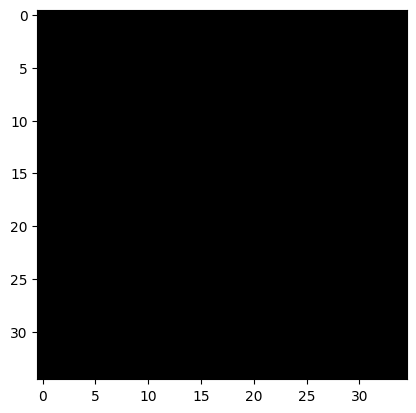

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10002.7333984375, epoch:44/1000


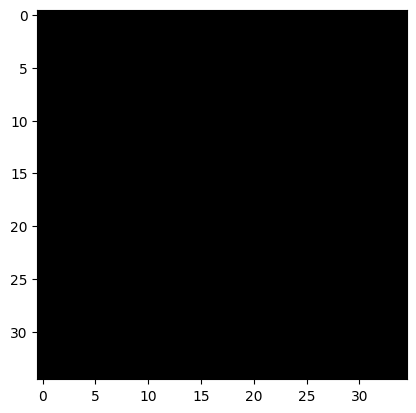

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9564.5126953125, epoch:45/1000


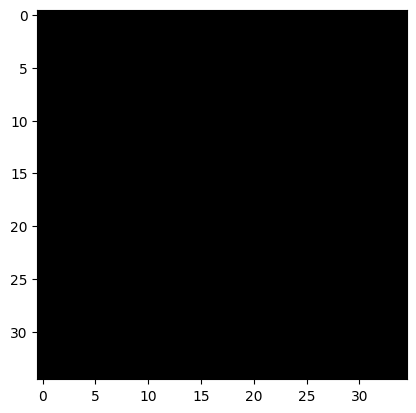

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9732.3193359375, epoch:46/1000


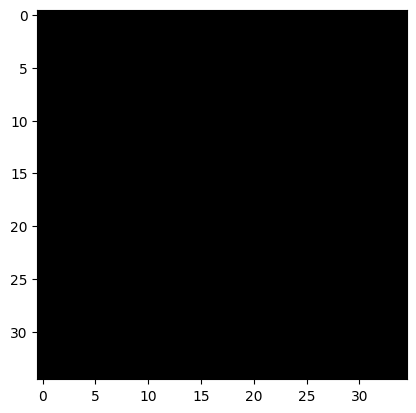

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 10122.533203125, epoch:47/1000


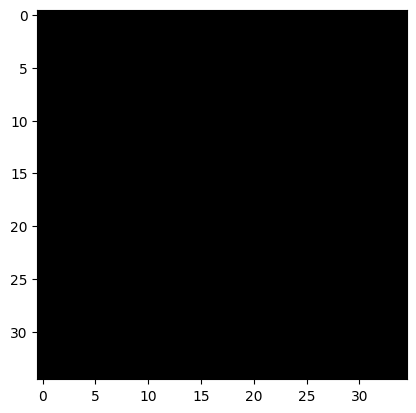

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9837.837890625, epoch:48/1000


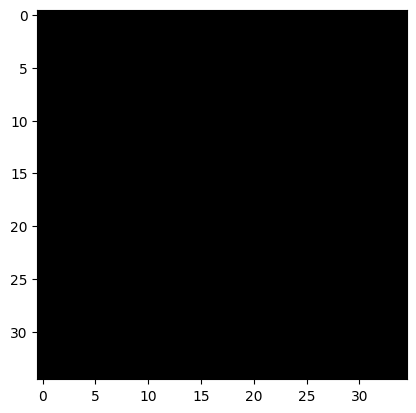

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10079.0185546875, epoch:49/1000


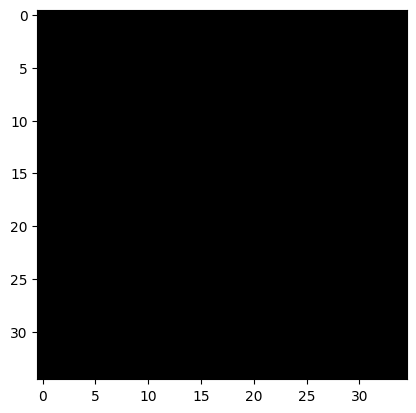

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10132.9560546875, epoch:50/1000


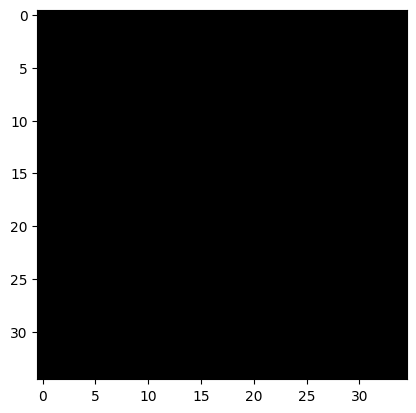

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9715.138671875, epoch:51/1000


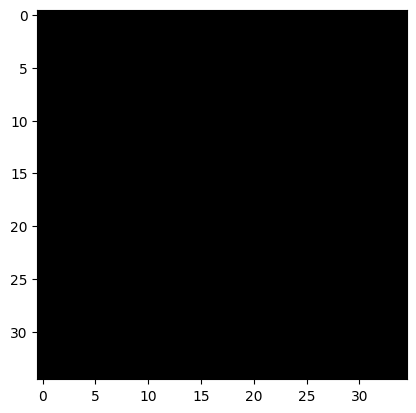

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9571.7734375, epoch:52/1000


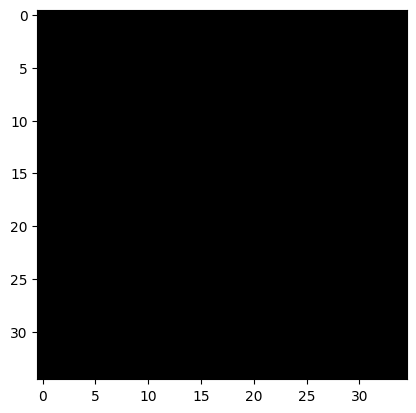

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9662.21875, epoch:53/1000


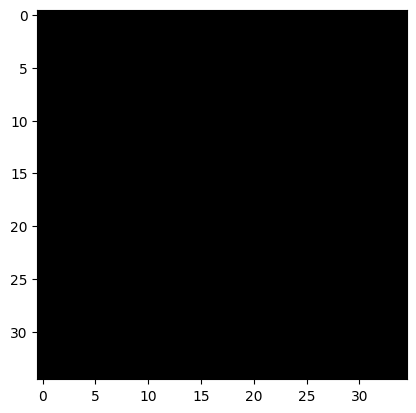

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10401.689453125, epoch:54/1000


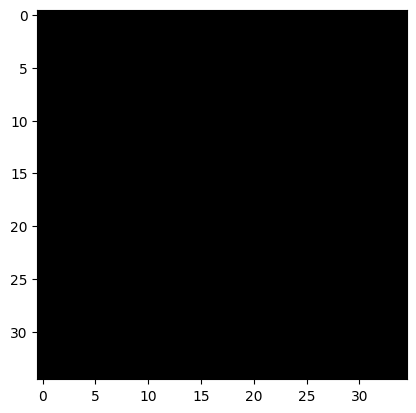

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10025.92578125, epoch:55/1000


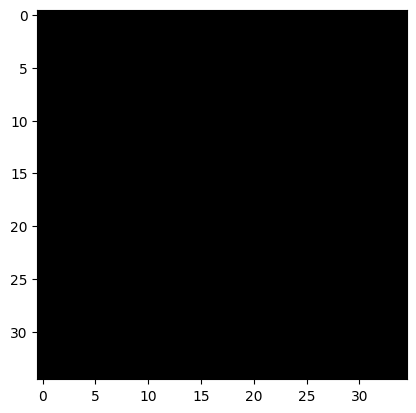

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9721.001953125, epoch:56/1000


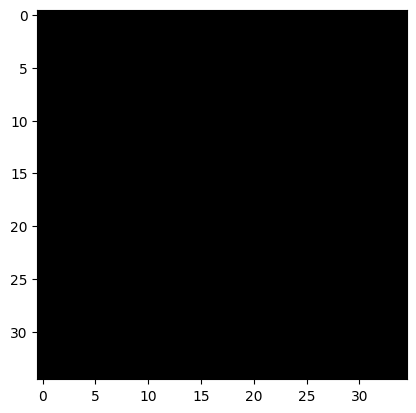

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10591.3447265625, epoch:57/1000


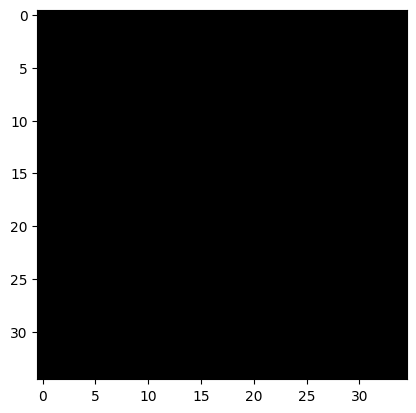

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 10156.330078125, epoch:58/1000


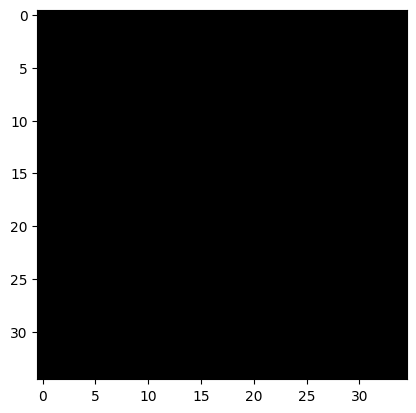

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9561.3193359375, epoch:59/1000


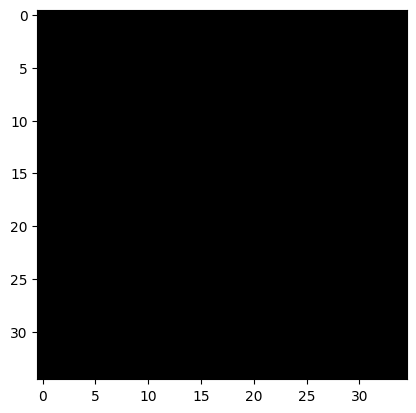

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9887.7353515625, epoch:60/1000


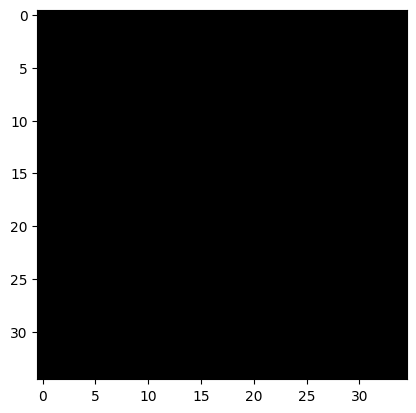

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9746.8232421875, epoch:61/1000


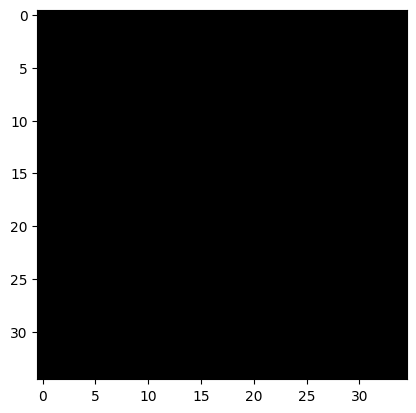

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10333.25, epoch:62/1000


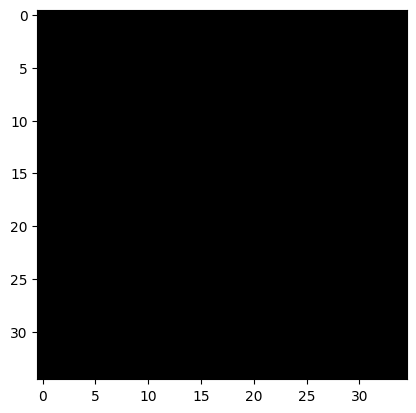

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10191.376953125, epoch:63/1000


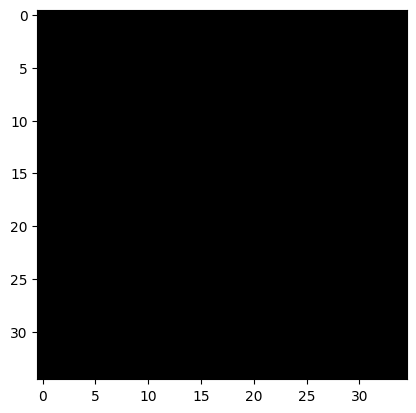

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10505.0439453125, epoch:64/1000


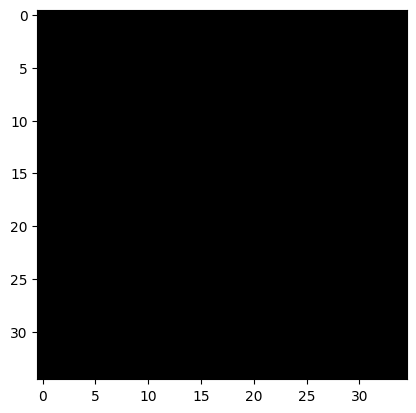

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 10123.703125, epoch:65/1000


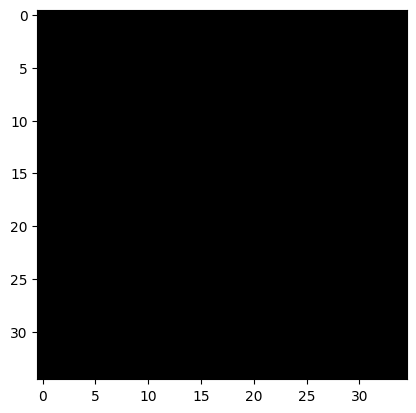

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9669.638671875, epoch:66/1000


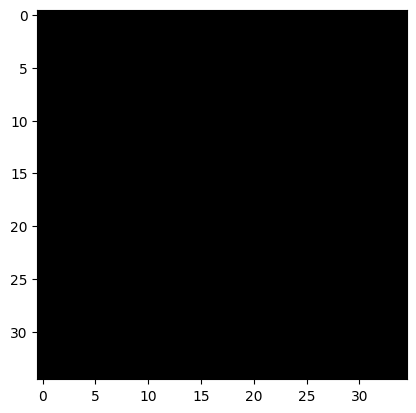

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9917.8330078125, epoch:67/1000


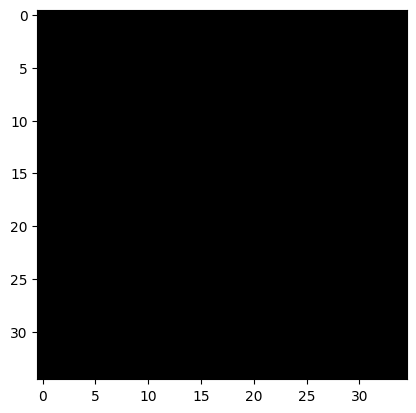

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9980.21484375, epoch:68/1000


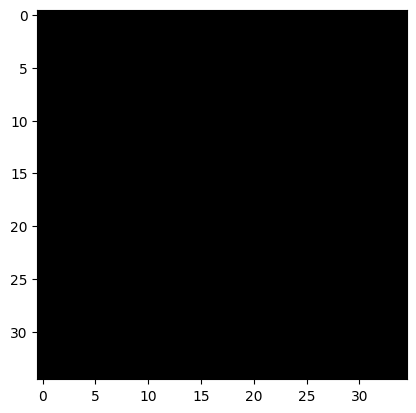

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9789.4716796875, epoch:69/1000


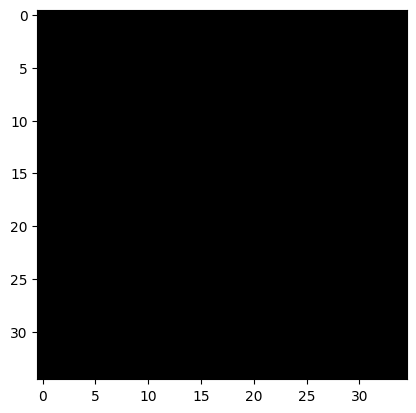

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9471.3291015625, epoch:70/1000


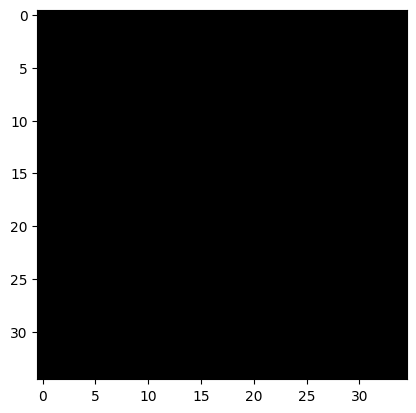

100%|██████████| 176/176 [01:02<00:00,  2.80it/s]


loss: 9908.619140625, epoch:71/1000


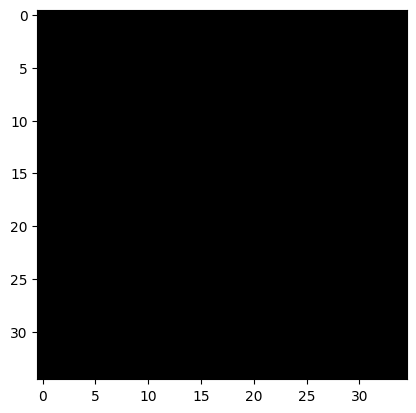

100%|██████████| 176/176 [01:03<00:00,  2.78it/s]


loss: 10166.267578125, epoch:72/1000


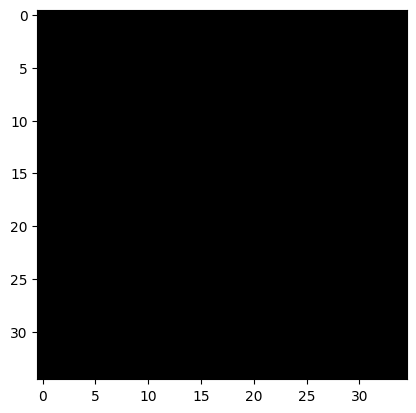

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9886.1025390625, epoch:73/1000


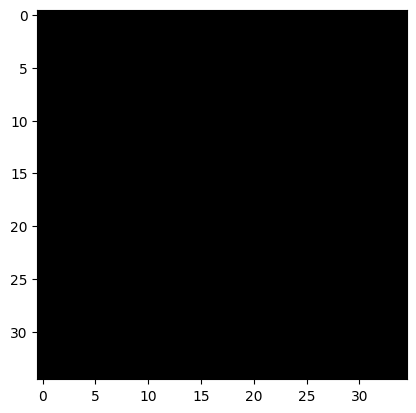

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10275.9833984375, epoch:74/1000


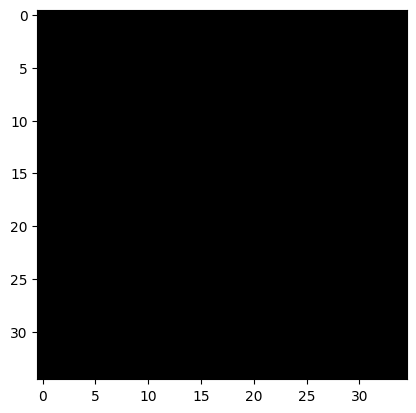

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9881.6708984375, epoch:75/1000


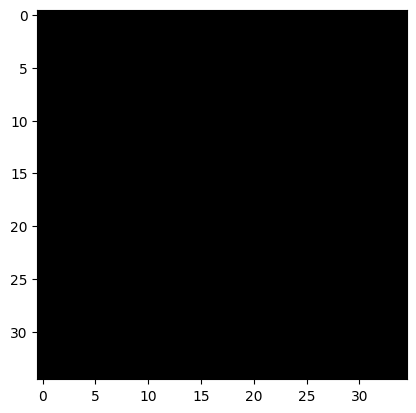

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10181.8984375, epoch:76/1000


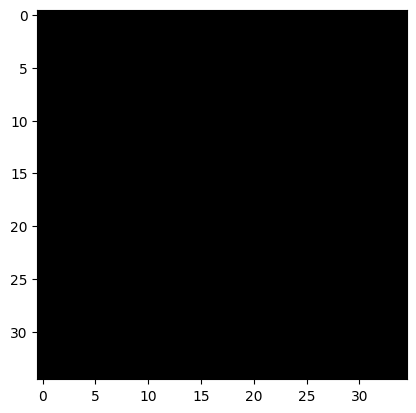

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9947.1298828125, epoch:77/1000


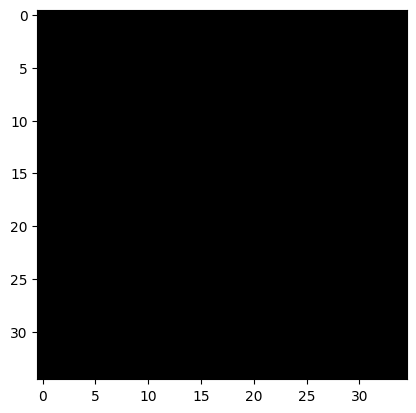

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9996.3251953125, epoch:78/1000


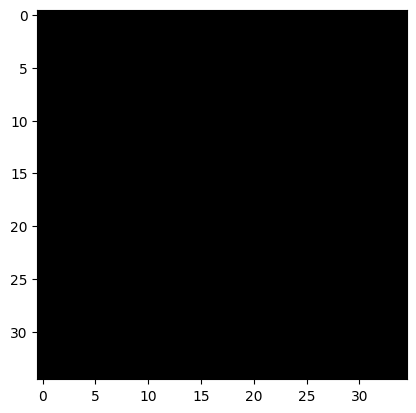

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10532.1396484375, epoch:79/1000


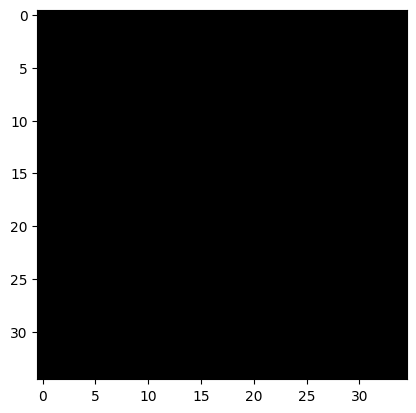

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9734.580078125, epoch:80/1000


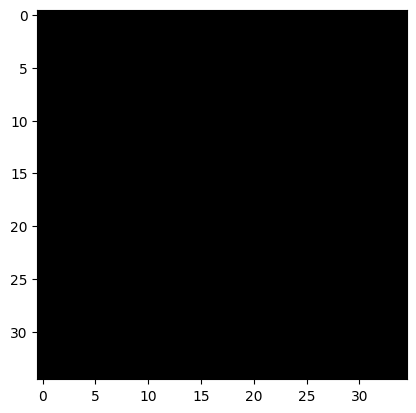

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9975.771484375, epoch:81/1000


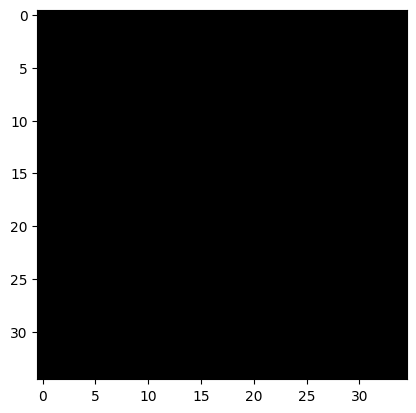

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9938.798828125, epoch:82/1000


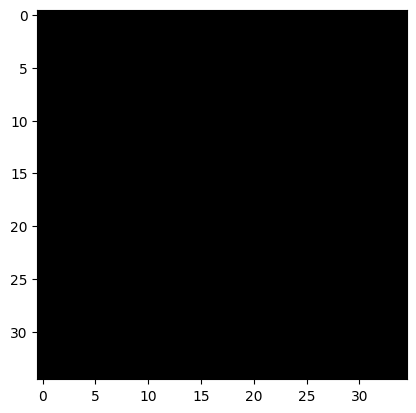

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 9720.072265625, epoch:83/1000


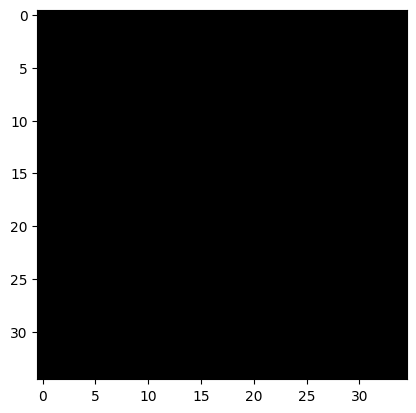

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9955.021484375, epoch:84/1000


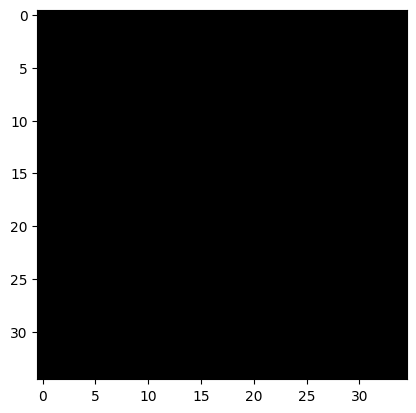

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9842.529296875, epoch:85/1000


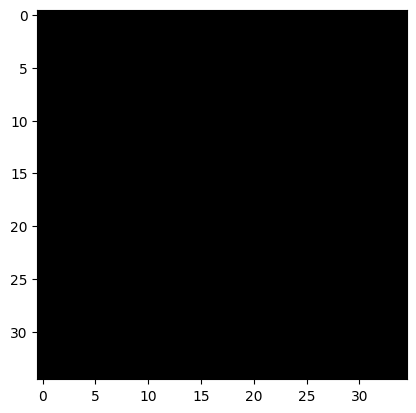

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9677.6953125, epoch:86/1000


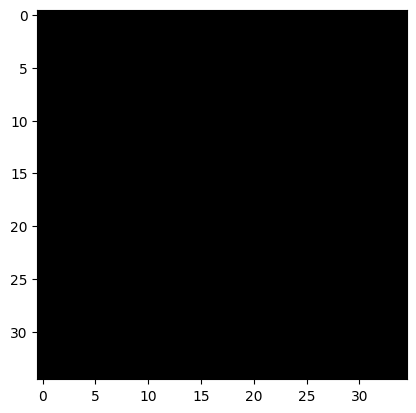

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9392.8447265625, epoch:87/1000


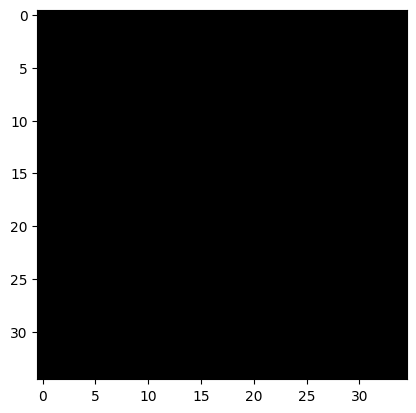

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 10051.9775390625, epoch:88/1000


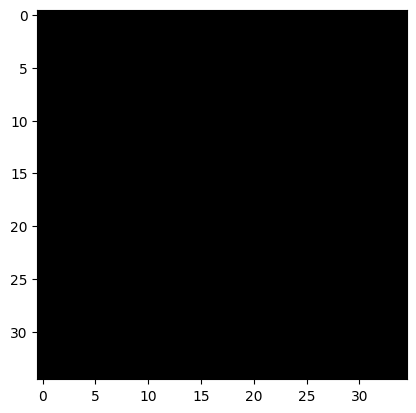

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 10141.3662109375, epoch:89/1000


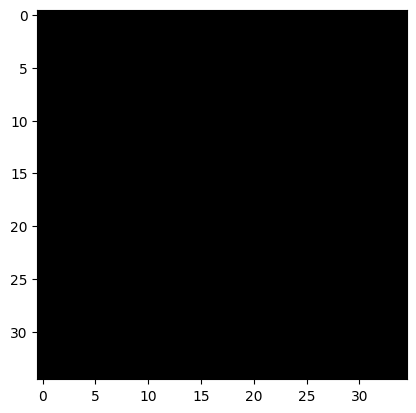

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10262.8466796875, epoch:90/1000


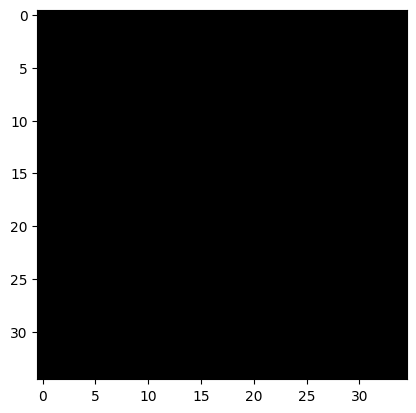

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 9824.4697265625, epoch:91/1000


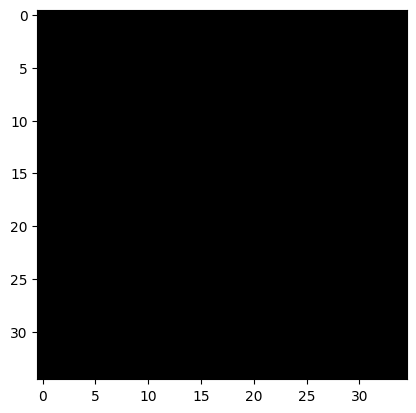

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9977.2939453125, epoch:92/1000


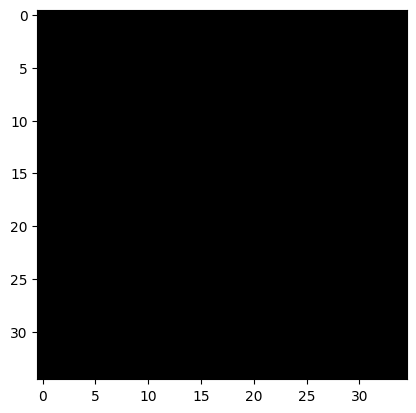

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10245.3330078125, epoch:93/1000


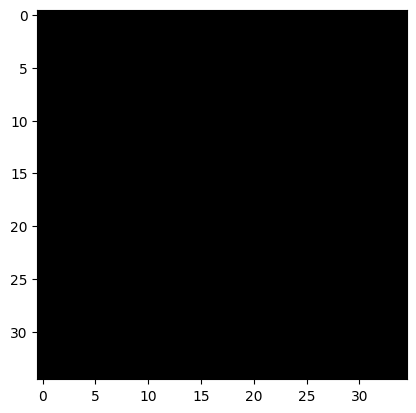

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9868.0, epoch:94/1000


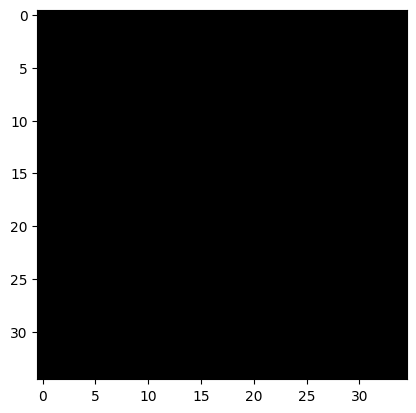

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9728.7294921875, epoch:95/1000


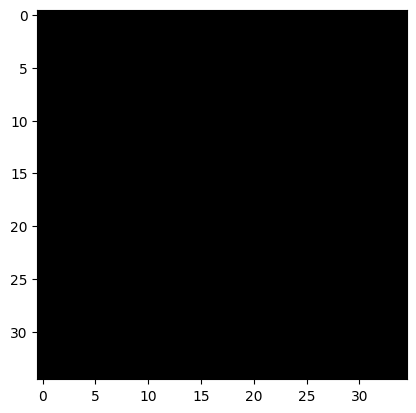

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9767.8505859375, epoch:96/1000


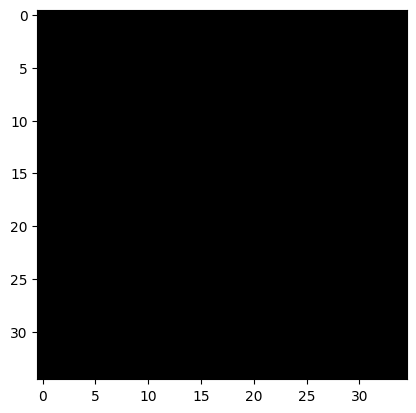

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 9847.060546875, epoch:97/1000


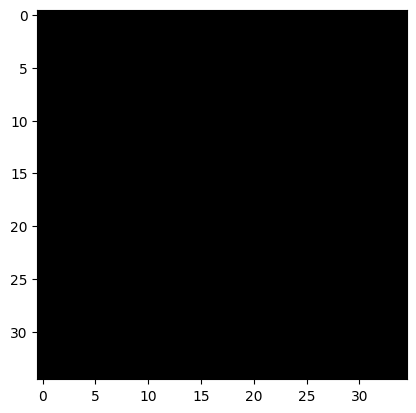

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9709.4697265625, epoch:98/1000


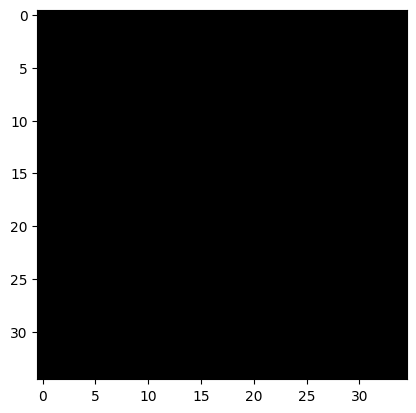

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 9971.8115234375, epoch:99/1000


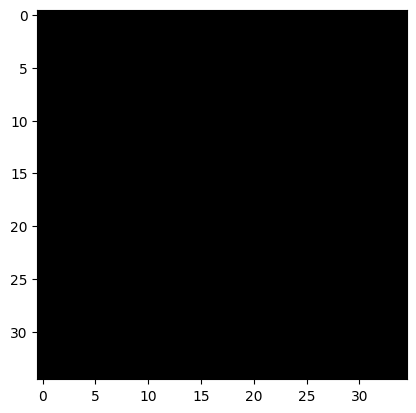

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9447.3369140625, epoch:100/1000


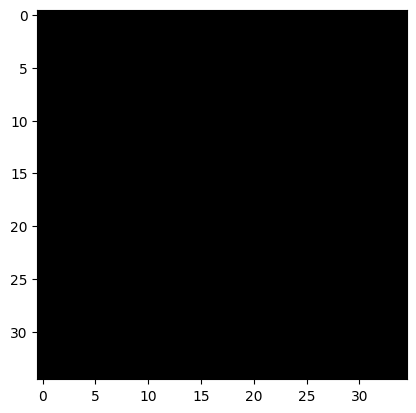

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9876.5888671875, epoch:101/1000


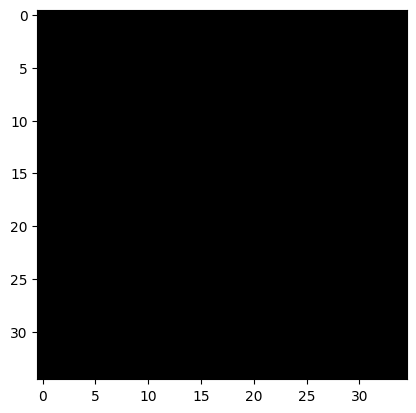

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10094.8017578125, epoch:102/1000


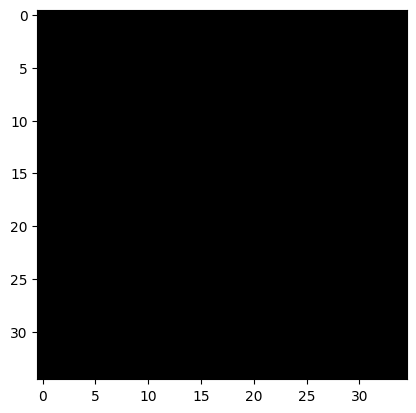

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9334.37890625, epoch:103/1000


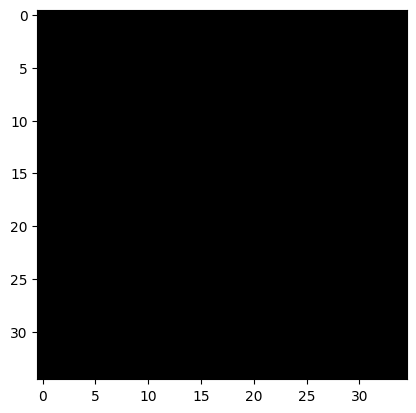

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9881.3349609375, epoch:104/1000


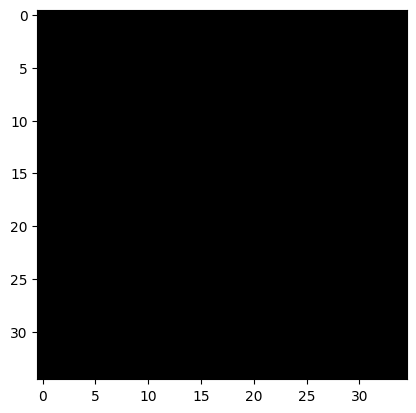

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9644.642578125, epoch:105/1000


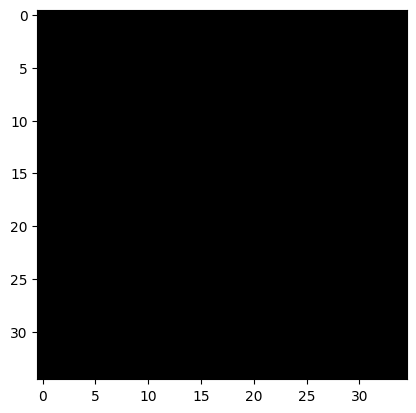

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9879.328125, epoch:106/1000


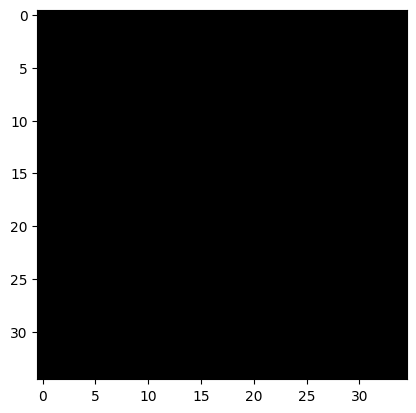

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9703.9580078125, epoch:107/1000


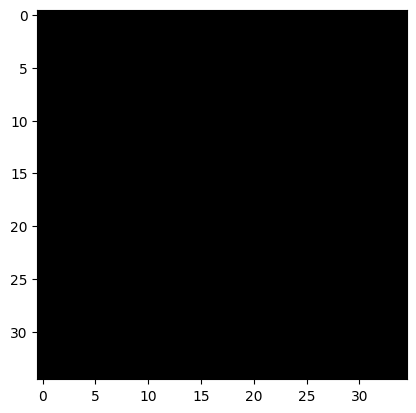

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9929.6171875, epoch:108/1000


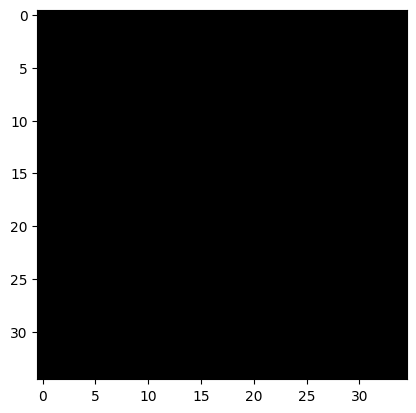

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9654.404296875, epoch:109/1000


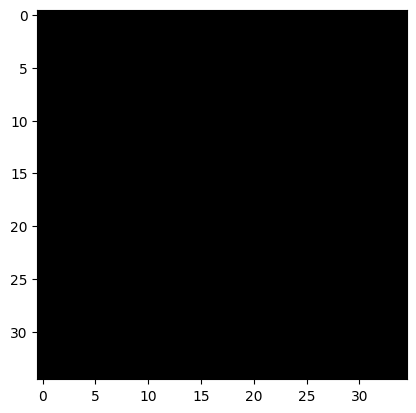

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]


loss: 9580.8984375, epoch:110/1000


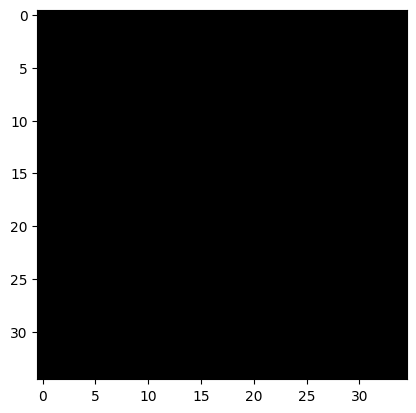

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]


loss: 9676.6181640625, epoch:111/1000


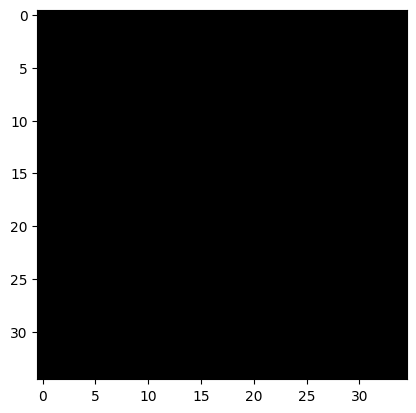

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9729.021484375, epoch:112/1000


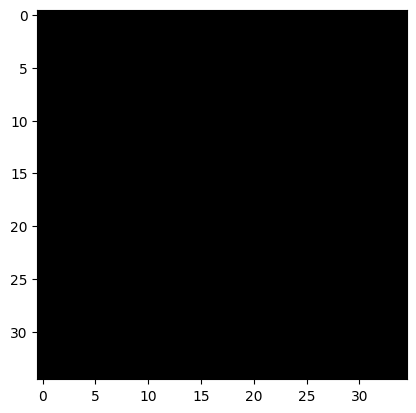

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9922.90625, epoch:113/1000


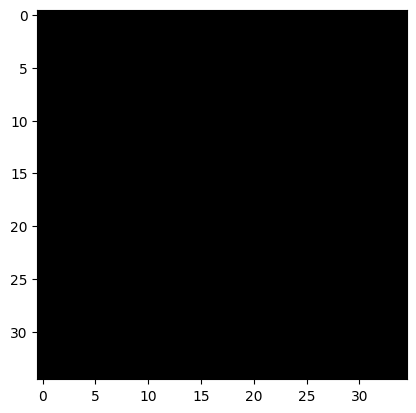

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9539.7705078125, epoch:114/1000


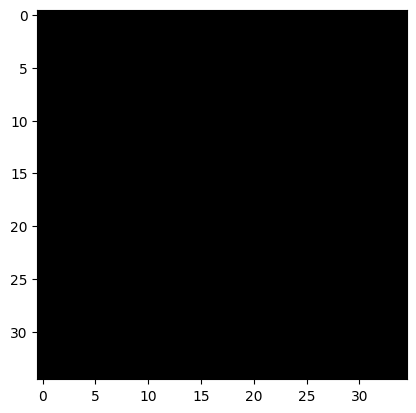

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9976.76953125, epoch:115/1000


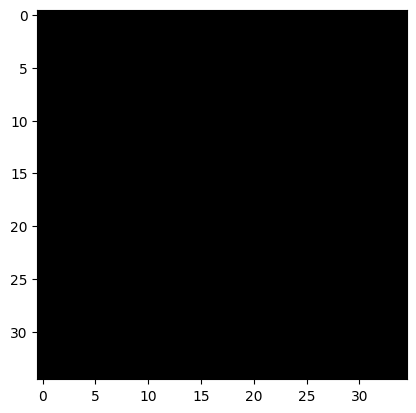

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9617.4794921875, epoch:116/1000


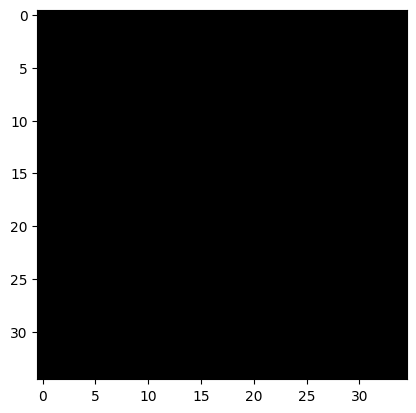

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9914.8291015625, epoch:117/1000


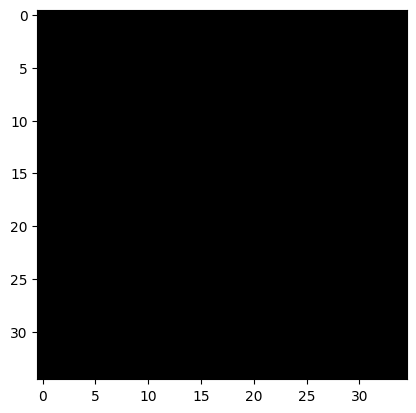

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10102.06640625, epoch:118/1000


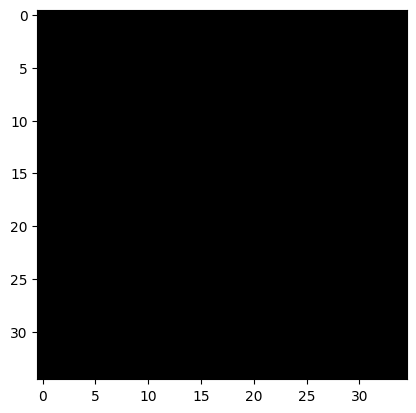

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9902.5283203125, epoch:119/1000


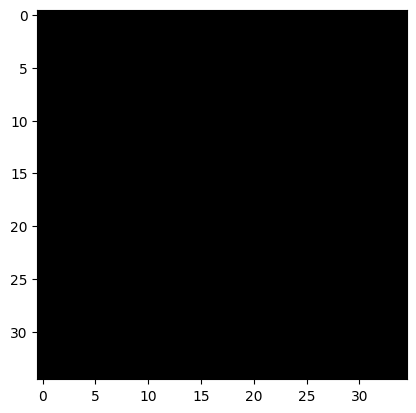

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9780.1123046875, epoch:120/1000


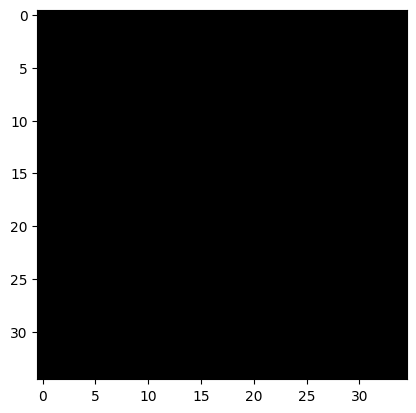

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9352.5576171875, epoch:121/1000


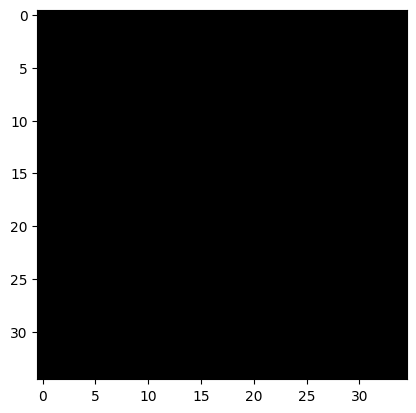

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10057.4423828125, epoch:122/1000


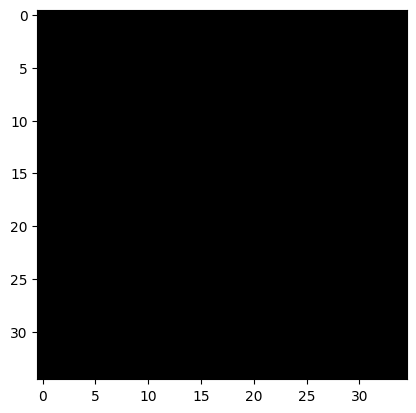

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9662.728515625, epoch:123/1000


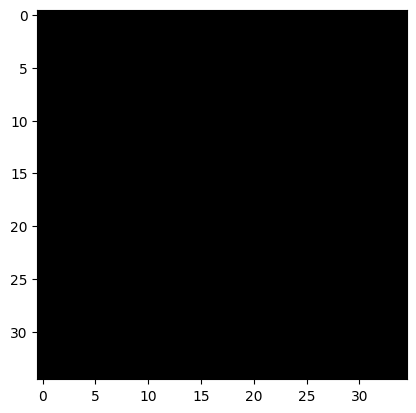

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9509.708984375, epoch:124/1000


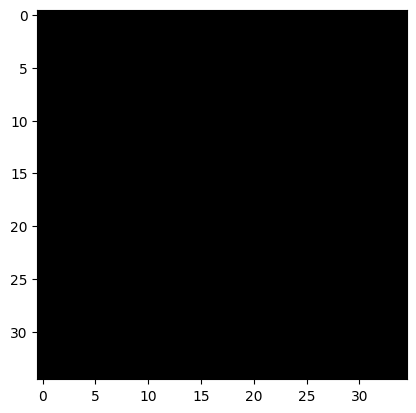

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10443.1162109375, epoch:125/1000


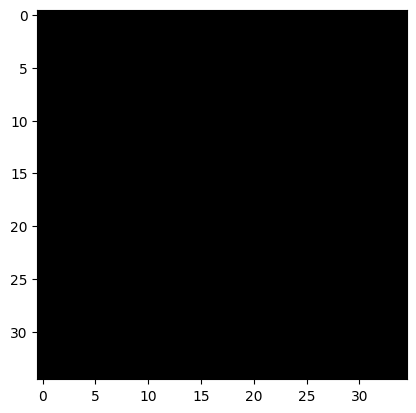

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10057.5068359375, epoch:126/1000


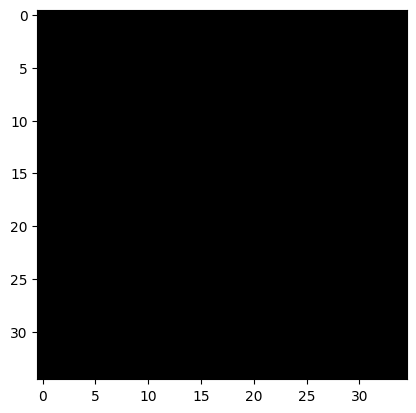

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10046.5361328125, epoch:127/1000


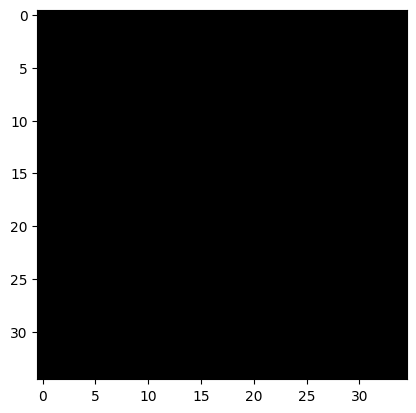

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10633.171875, epoch:128/1000


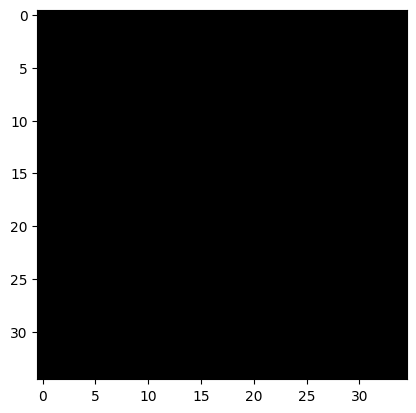

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 9584.2890625, epoch:129/1000


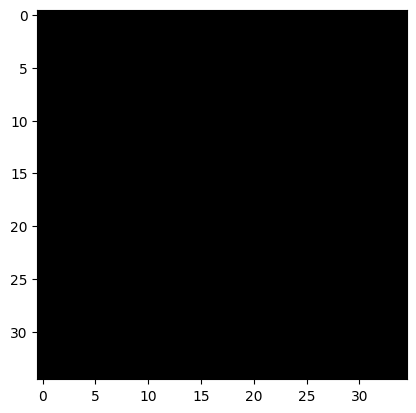

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9513.8017578125, epoch:130/1000


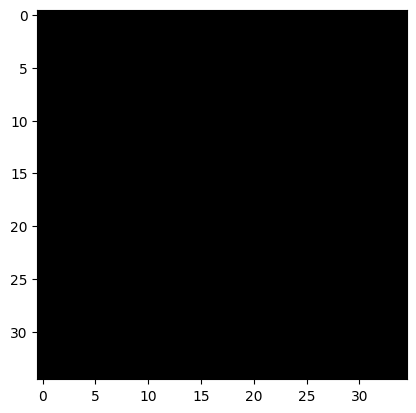

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10247.1171875, epoch:131/1000


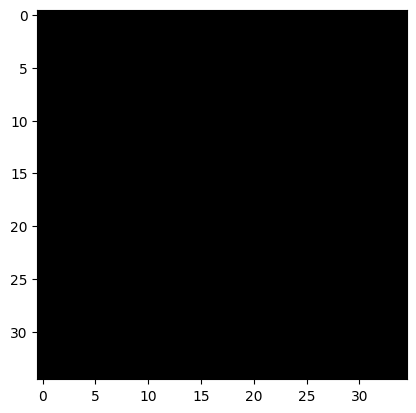

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10117.787109375, epoch:132/1000


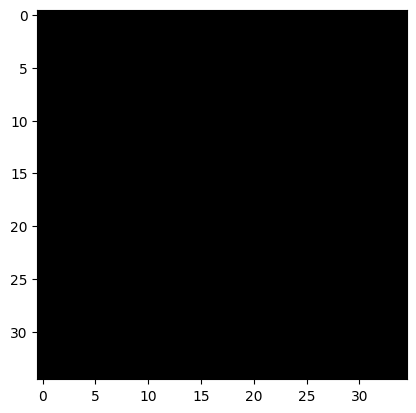

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9504.0166015625, epoch:133/1000


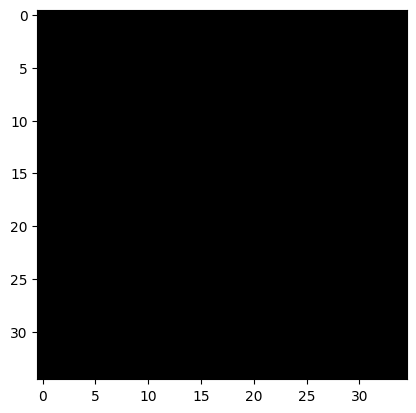

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9888.771484375, epoch:134/1000


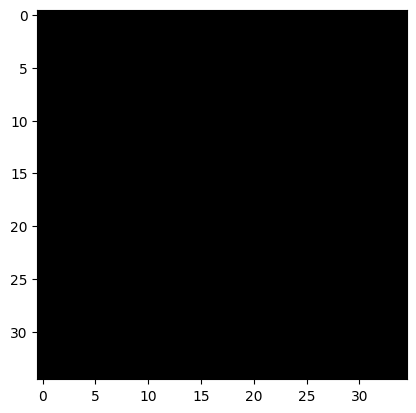

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9460.6630859375, epoch:135/1000


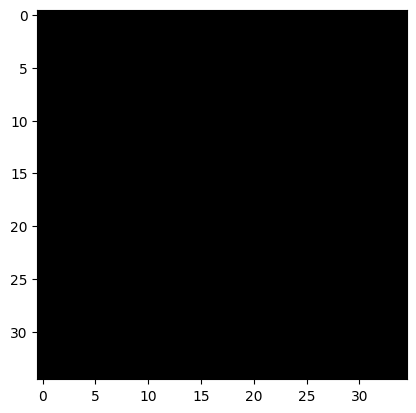

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9652.29296875, epoch:136/1000


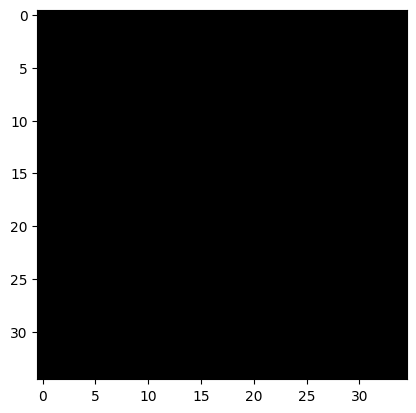

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9659.6298828125, epoch:137/1000


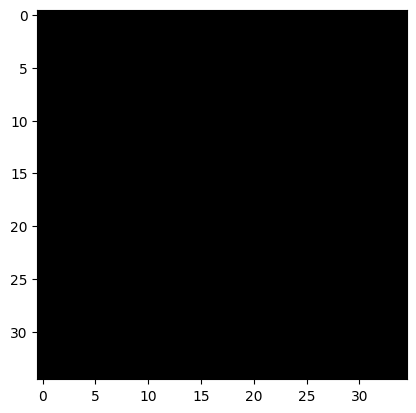

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9948.4609375, epoch:138/1000


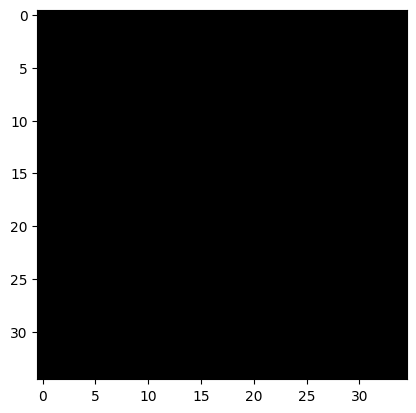

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9647.4990234375, epoch:139/1000


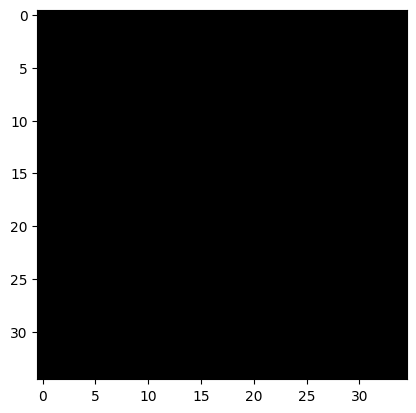

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9828.5234375, epoch:140/1000


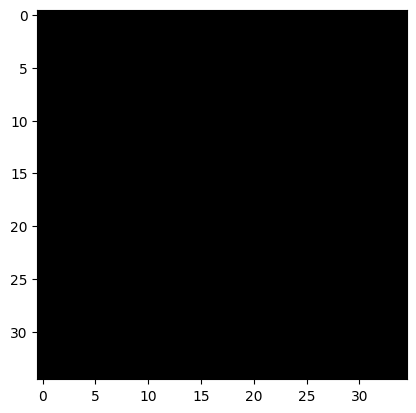

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9833.8505859375, epoch:141/1000


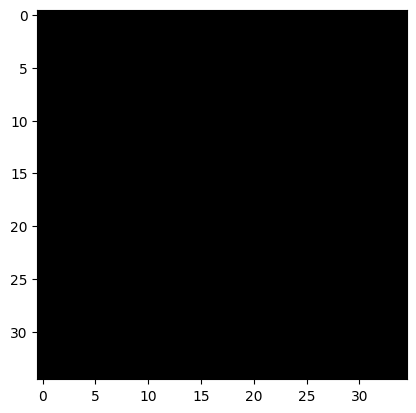

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9656.90234375, epoch:142/1000


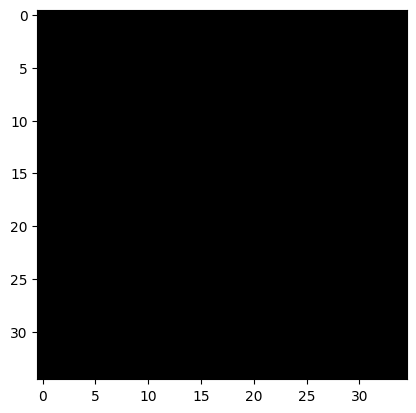

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9902.802734375, epoch:143/1000


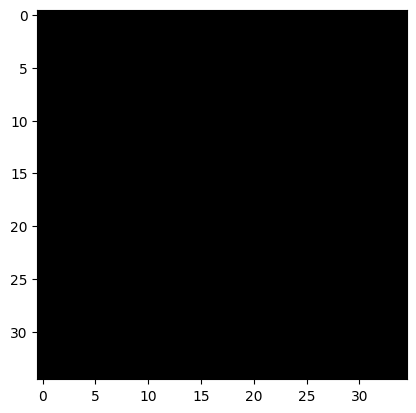

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9747.7177734375, epoch:144/1000


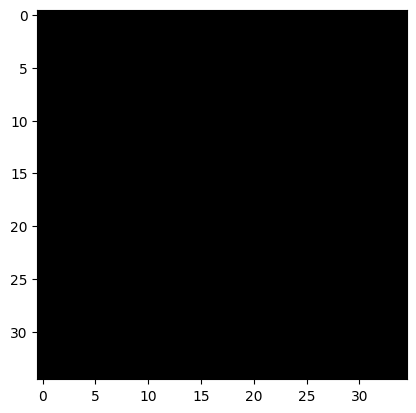

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 10283.94140625, epoch:145/1000


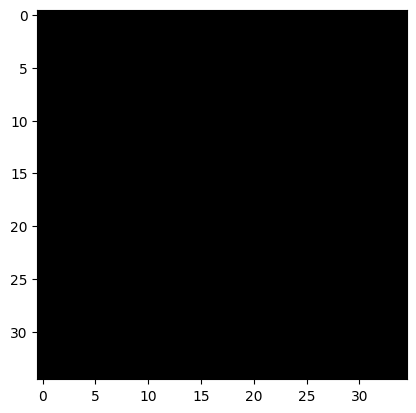

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10381.150390625, epoch:146/1000


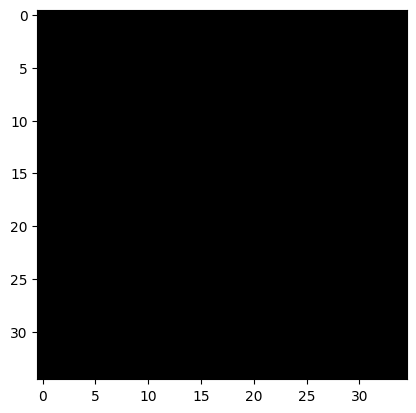

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9741.740234375, epoch:147/1000


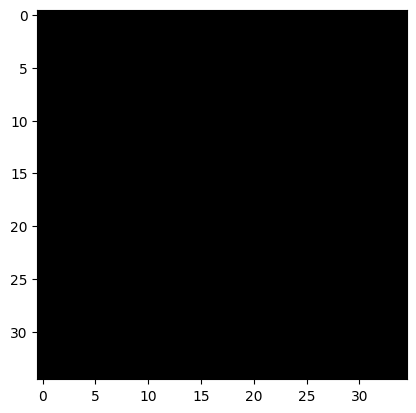

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 9858.2099609375, epoch:148/1000


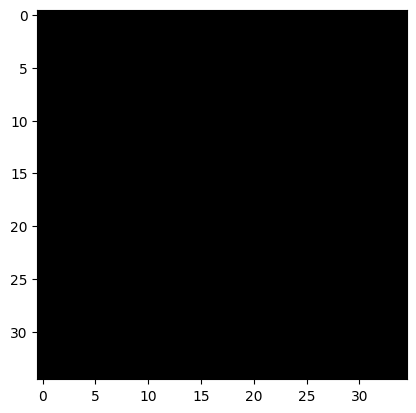

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 10047.1455078125, epoch:149/1000


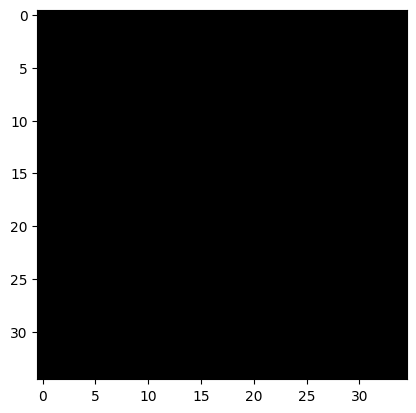

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9782.19140625, epoch:150/1000


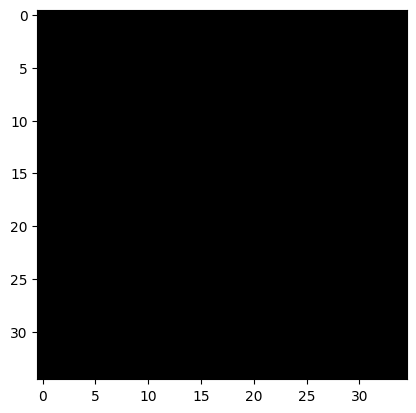

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10314.833984375, epoch:151/1000


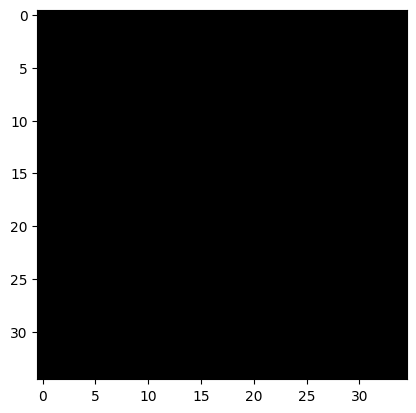

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10514.666015625, epoch:152/1000


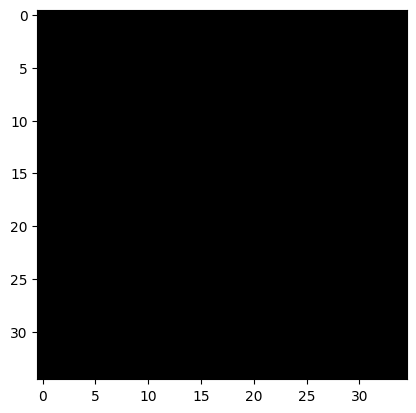

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10299.3212890625, epoch:153/1000


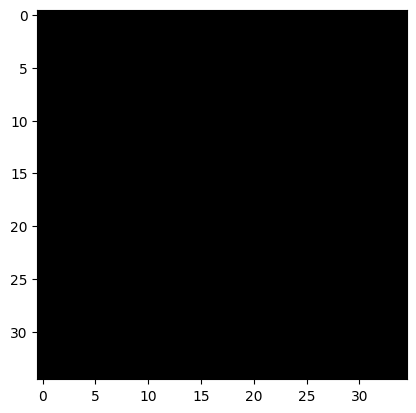

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9992.408203125, epoch:154/1000


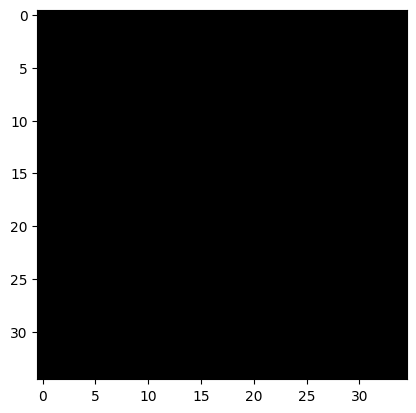

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9791.349609375, epoch:155/1000


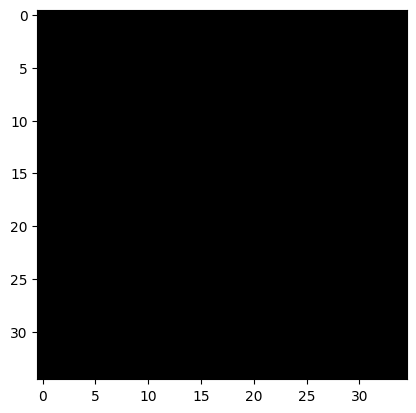

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9526.8740234375, epoch:156/1000


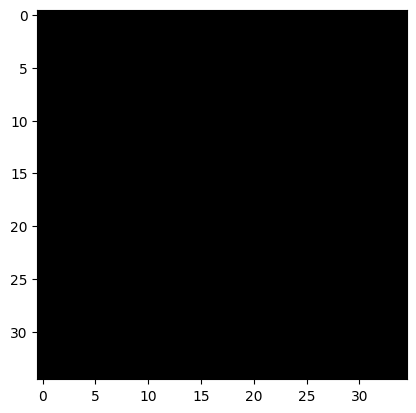

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9820.9775390625, epoch:157/1000


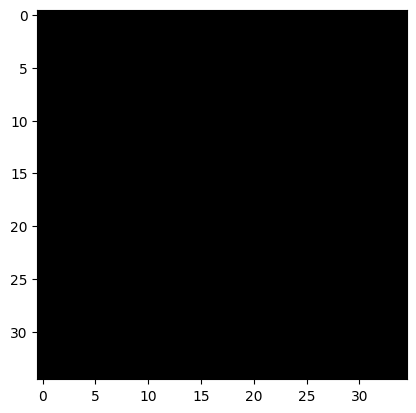

100%|██████████| 176/176 [01:02<00:00,  2.82it/s]


loss: 10094.908203125, epoch:158/1000


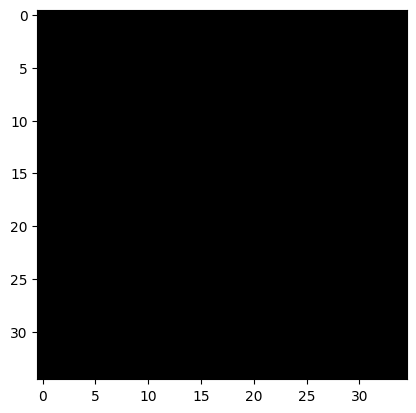

100%|██████████| 176/176 [01:02<00:00,  2.81it/s]

loss: 9947.068359375, epoch:159/1000


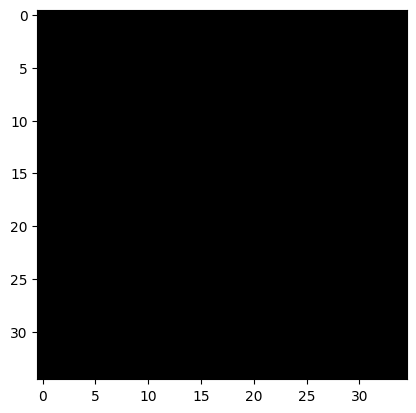

100%|██████████| 176/176 [01:02<00:00,  2.80it/s]


loss: 10264.8818359375, epoch:160/1000


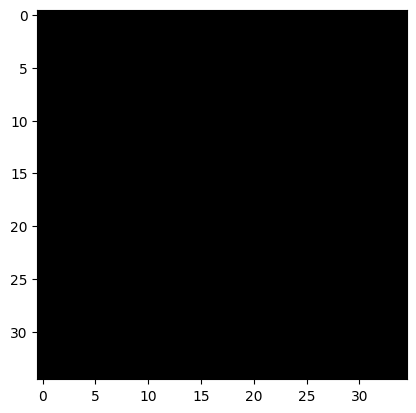

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9635.138671875, epoch:161/1000


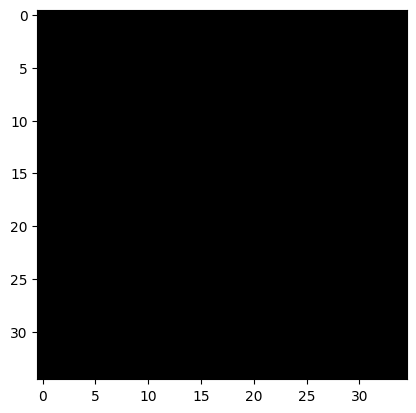

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9700.1259765625, epoch:162/1000


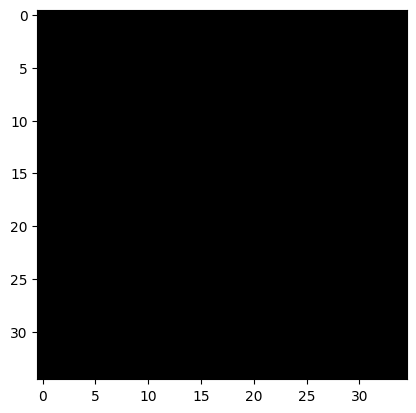

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10311.544921875, epoch:163/1000


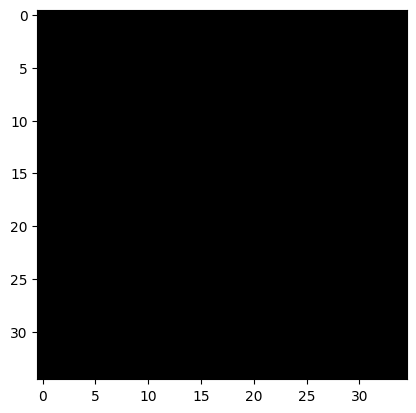

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9562.921875, epoch:164/1000


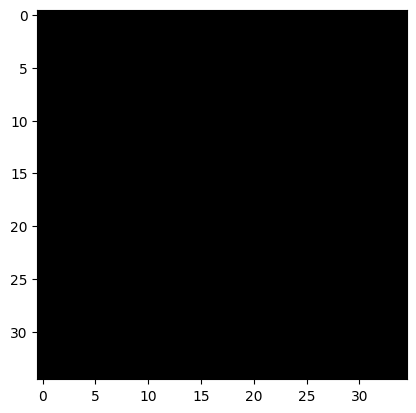

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9712.978515625, epoch:165/1000


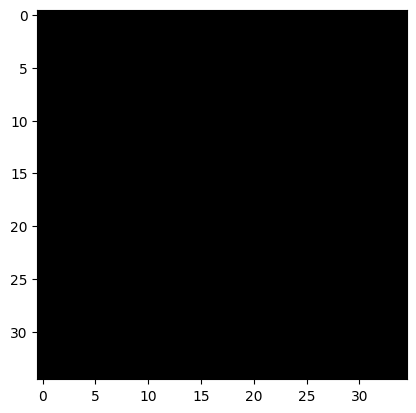

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 10008.1142578125, epoch:166/1000


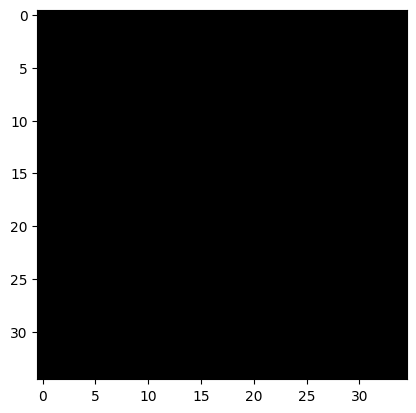

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9572.228515625, epoch:167/1000


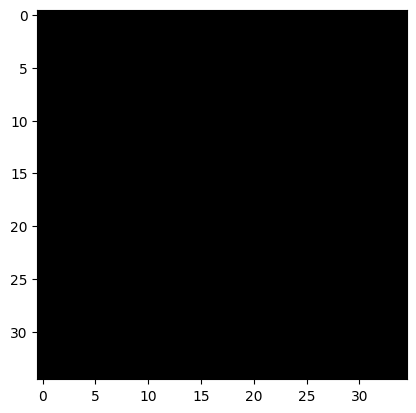

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9649.52734375, epoch:168/1000


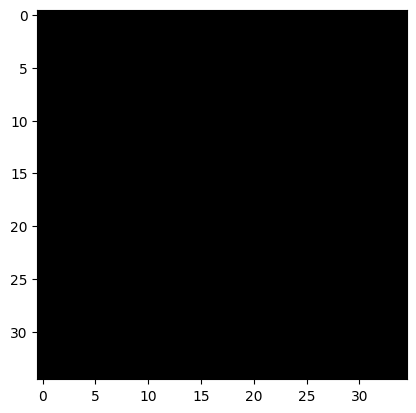

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9822.9326171875, epoch:169/1000


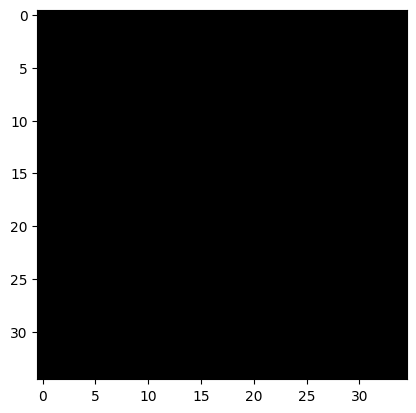

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9584.9775390625, epoch:170/1000


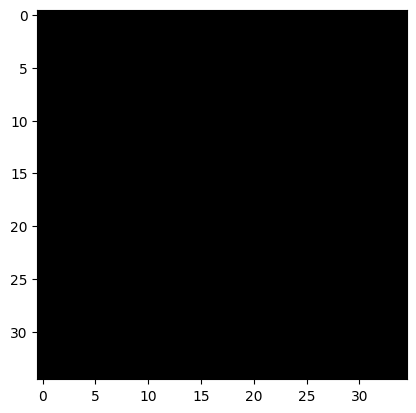

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9616.6298828125, epoch:171/1000


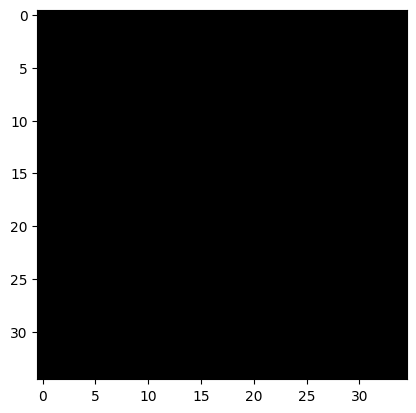

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9955.876953125, epoch:172/1000


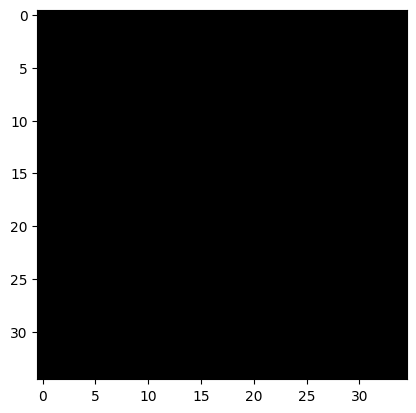

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]

loss: 9693.955078125, epoch:173/1000


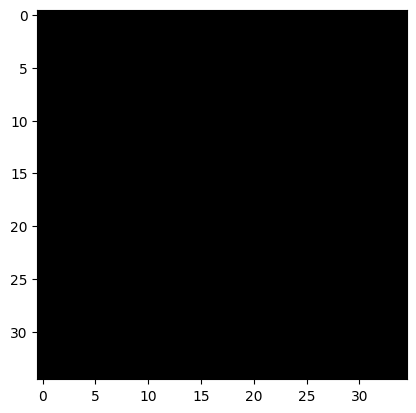

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10323.734375, epoch:174/1000


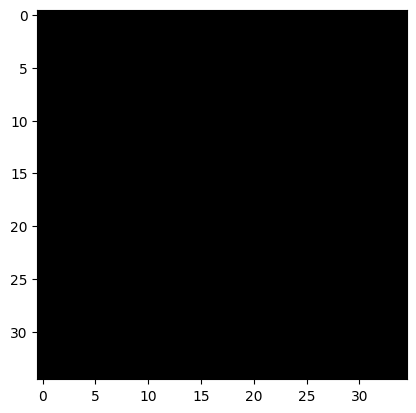

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10101.1123046875, epoch:175/1000


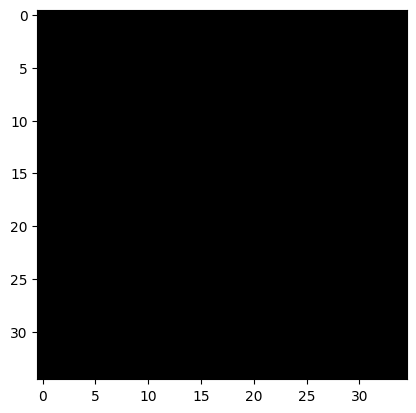

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10048.1796875, epoch:176/1000


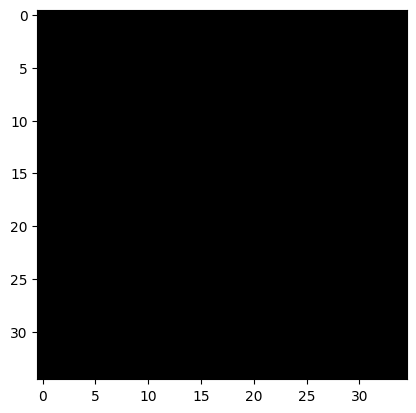

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10041.8818359375, epoch:177/1000


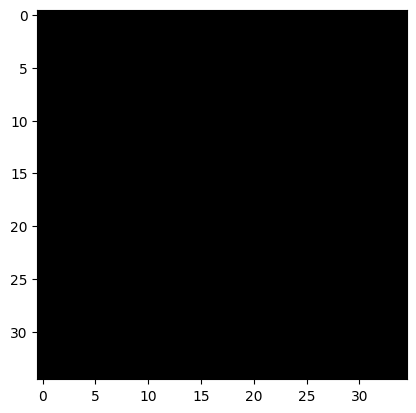

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 10217.046875, epoch:178/1000


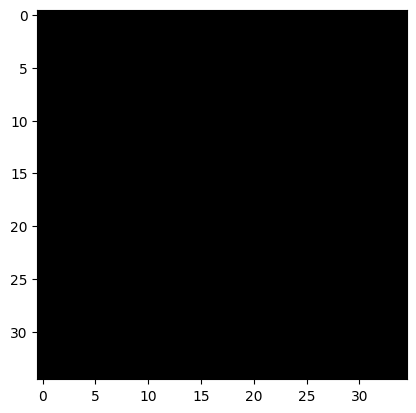

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9791.3818359375, epoch:179/1000


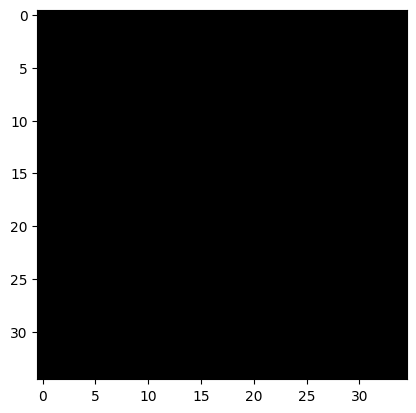

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10169.9619140625, epoch:180/1000


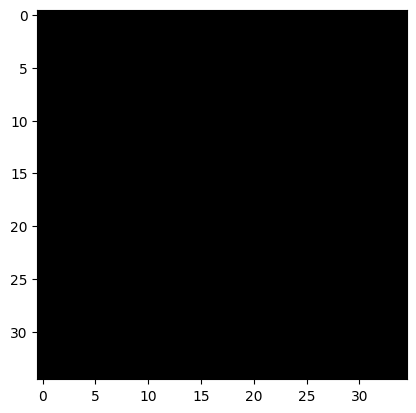

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10052.5302734375, epoch:181/1000


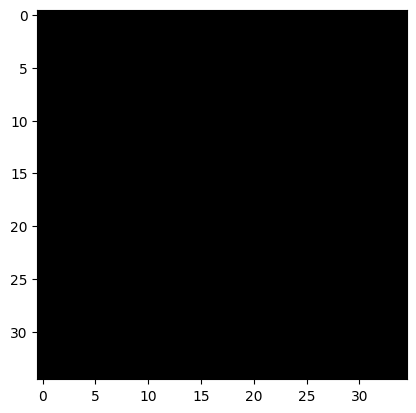

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9750.0224609375, epoch:182/1000


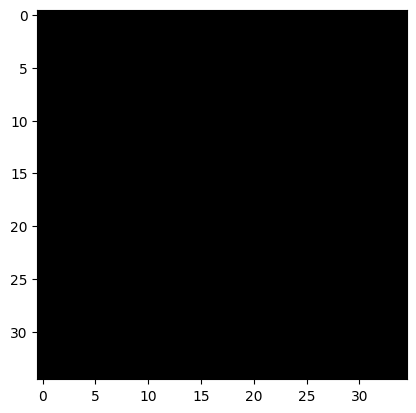

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9651.1748046875, epoch:183/1000


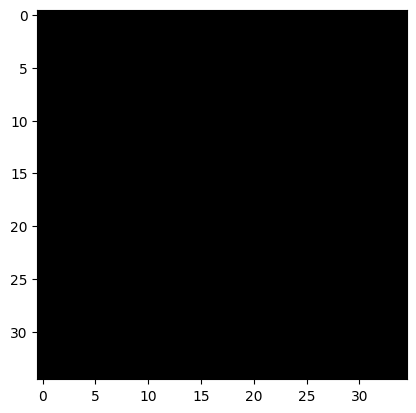

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9569.1796875, epoch:184/1000


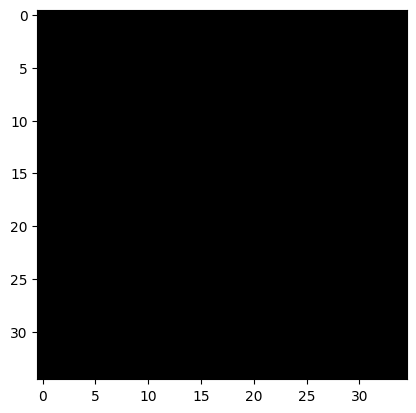

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9877.7451171875, epoch:185/1000


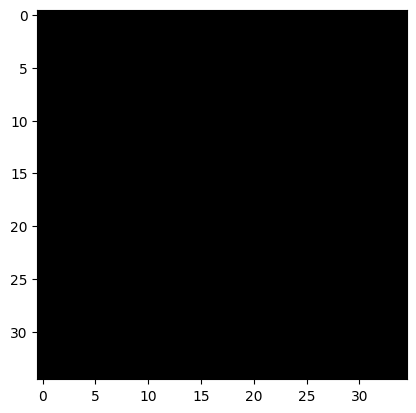

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]


loss: 10237.900390625, epoch:186/1000


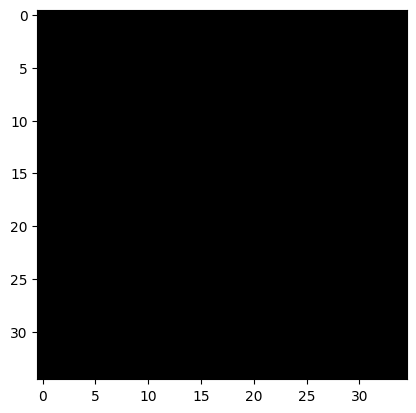

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]


loss: 9923.49609375, epoch:187/1000


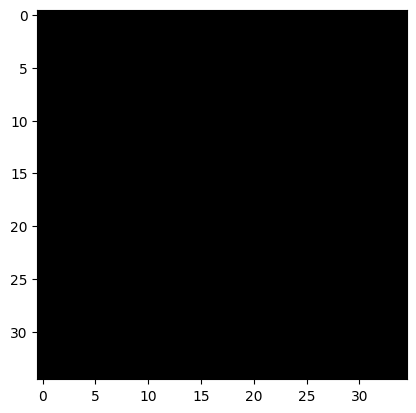

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9858.67578125, epoch:188/1000


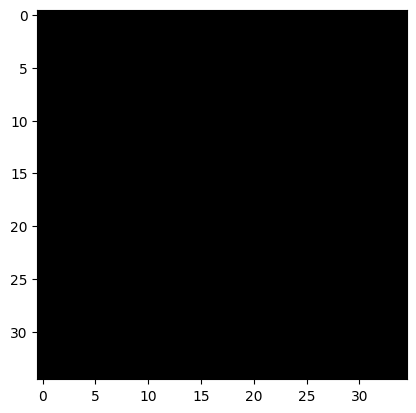

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10031.232421875, epoch:189/1000


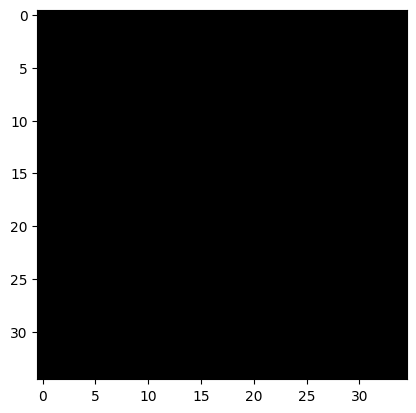

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9552.880859375, epoch:190/1000


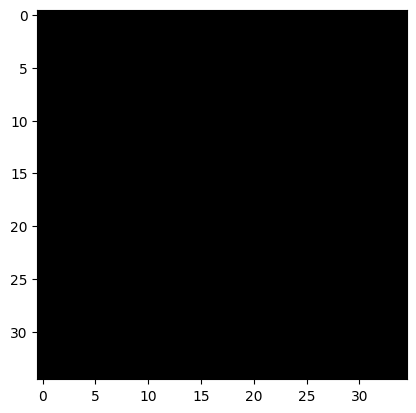

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9789.8515625, epoch:191/1000


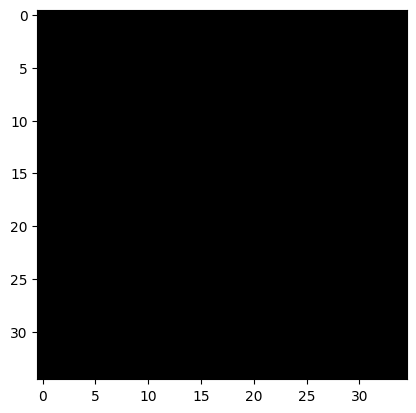

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10093.8291015625, epoch:192/1000


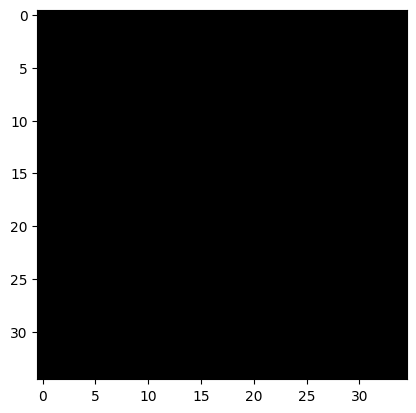

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9833.9560546875, epoch:193/1000


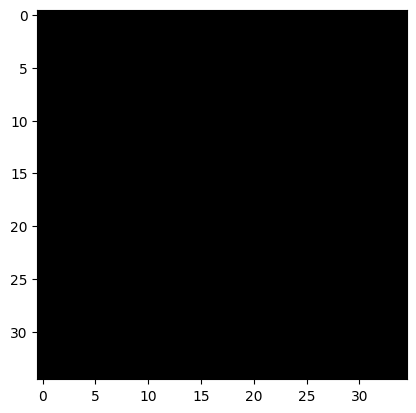

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9910.72265625, epoch:194/1000


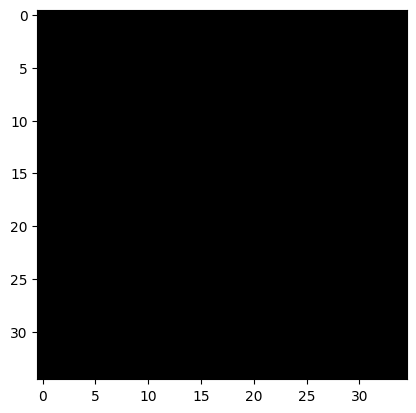

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9739.080078125, epoch:195/1000


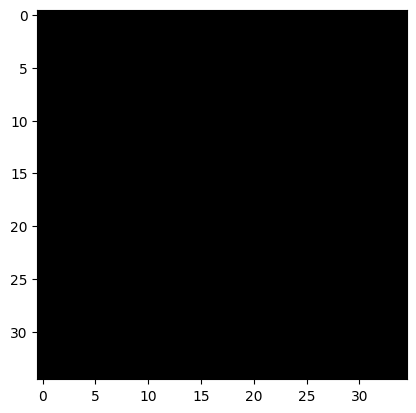

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9832.6259765625, epoch:196/1000


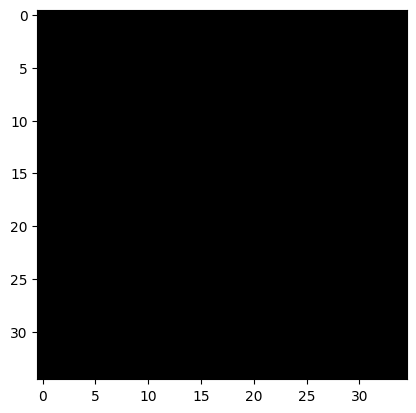

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9656.6103515625, epoch:197/1000


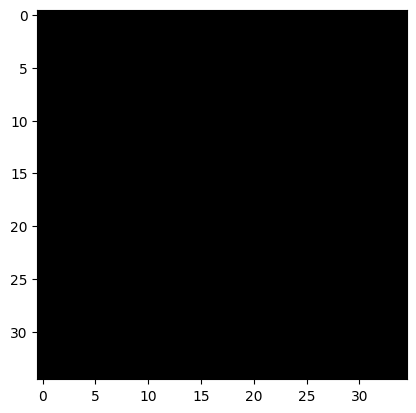

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9796.017578125, epoch:198/1000


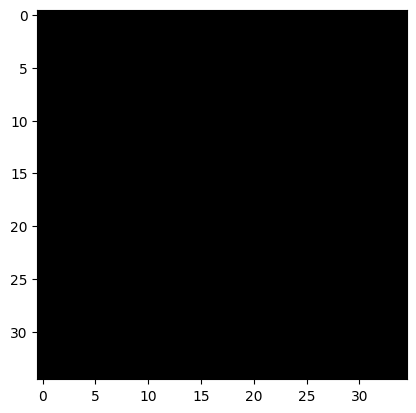

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10238.517578125, epoch:199/1000


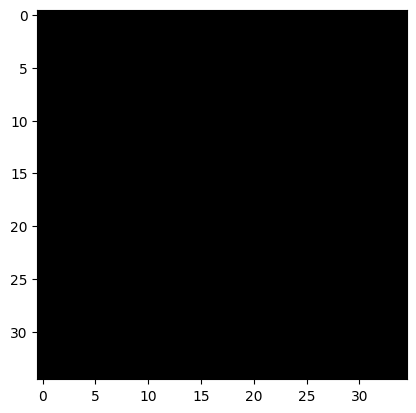

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10407.384765625, epoch:200/1000


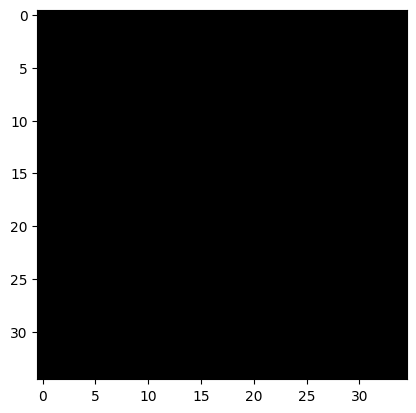

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9783.2548828125, epoch:201/1000


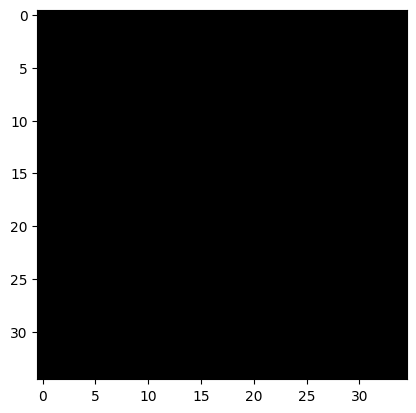

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9646.4814453125, epoch:202/1000


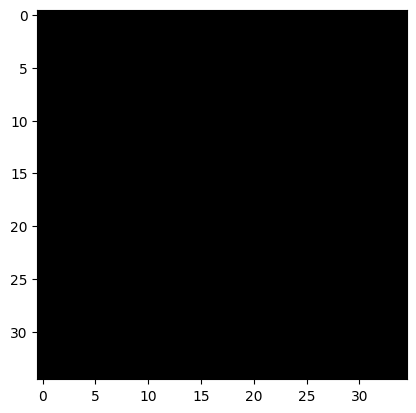

100%|██████████| 176/176 [01:02<00:00,  2.81it/s]


loss: 10061.1884765625, epoch:203/1000


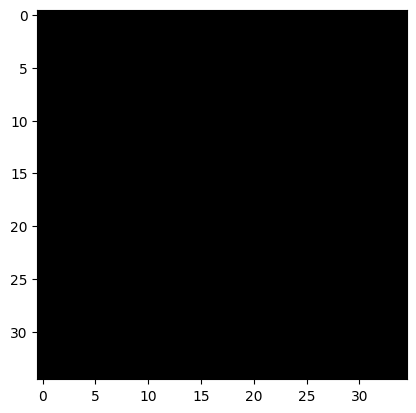

100%|██████████| 176/176 [01:03<00:00,  2.78it/s]

loss: 9094.2060546875, epoch:204/1000


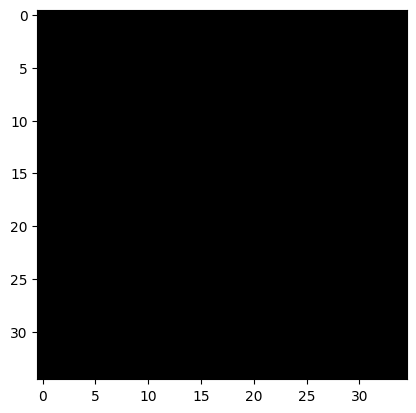

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10004.7216796875, epoch:205/1000


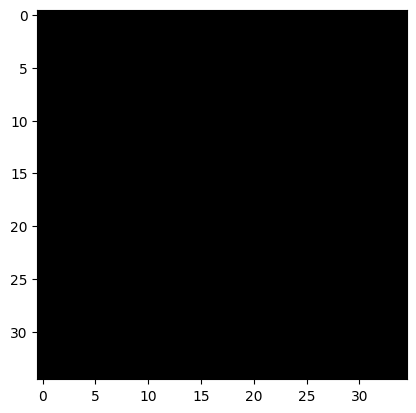

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 10146.919921875, epoch:206/1000


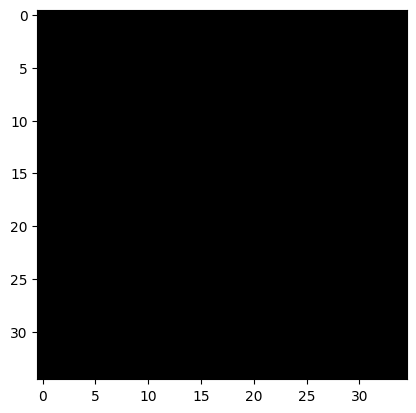

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9975.2919921875, epoch:207/1000


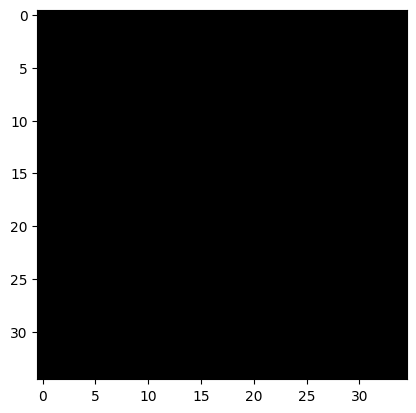

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10197.0498046875, epoch:208/1000


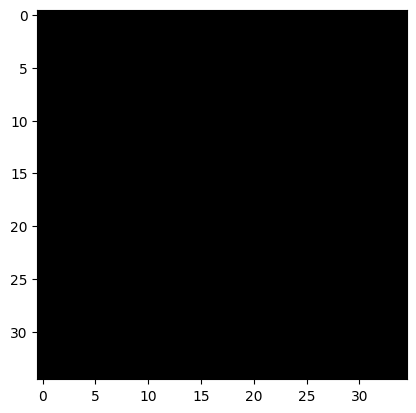

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 9641.1767578125, epoch:209/1000


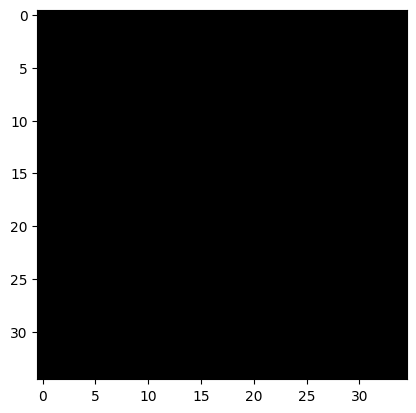

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10092.4892578125, epoch:210/1000


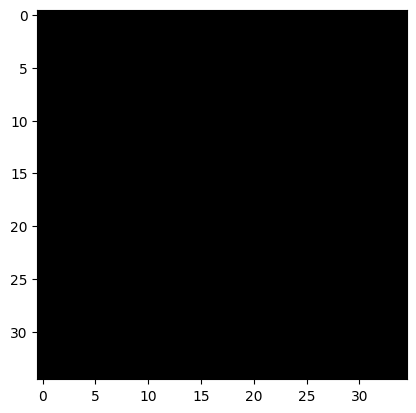

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9939.986328125, epoch:211/1000


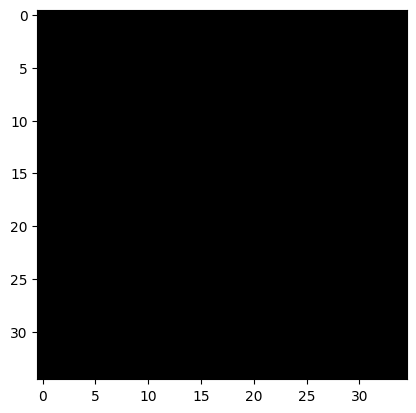

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9459.0888671875, epoch:212/1000


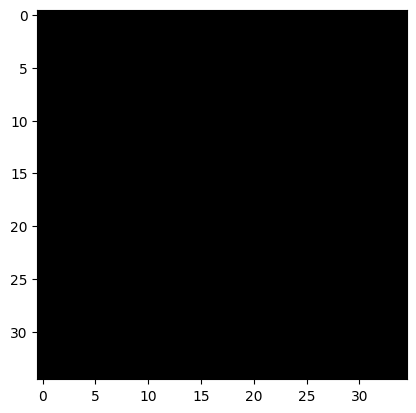

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9735.58203125, epoch:213/1000


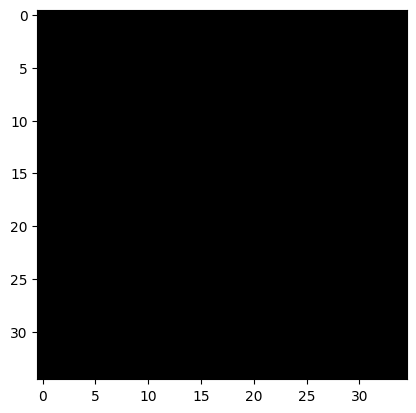

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9978.71875, epoch:214/1000


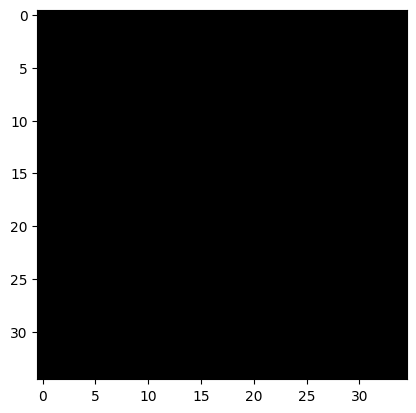

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 9630.1337890625, epoch:215/1000


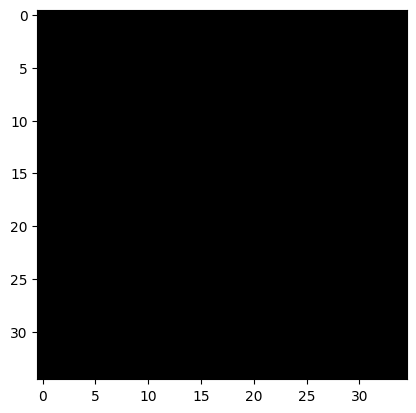

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9931.3857421875, epoch:216/1000


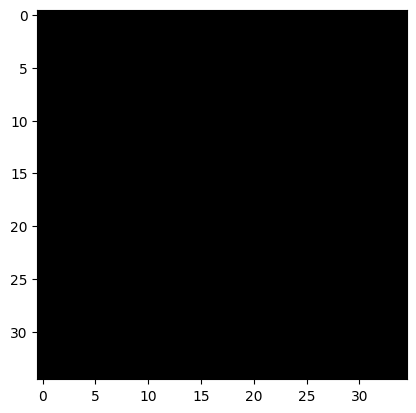

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10079.408203125, epoch:217/1000


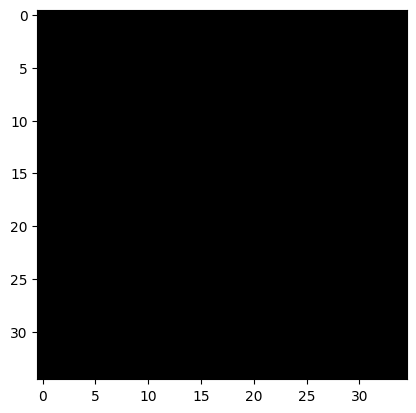

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9393.146484375, epoch:218/1000


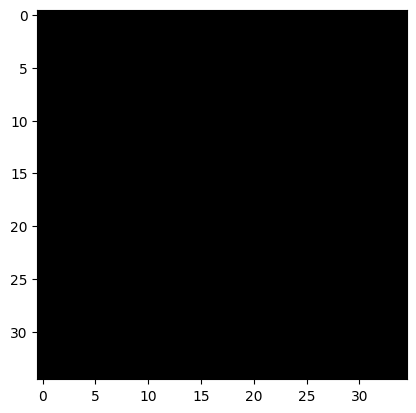

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9728.75390625, epoch:219/1000


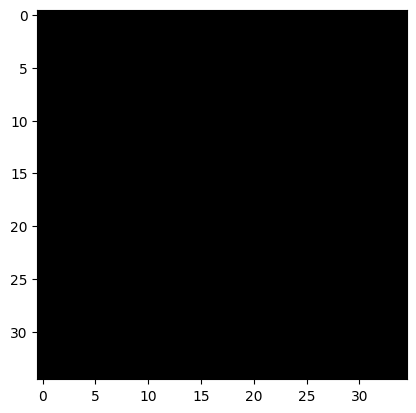

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9928.5283203125, epoch:220/1000


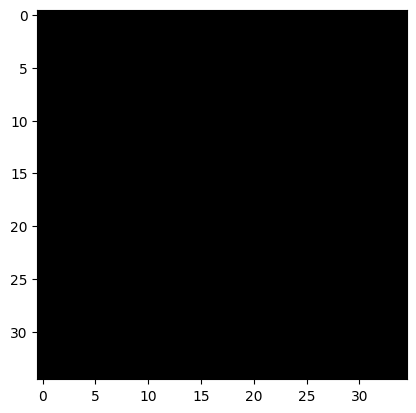

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9844.6396484375, epoch:221/1000


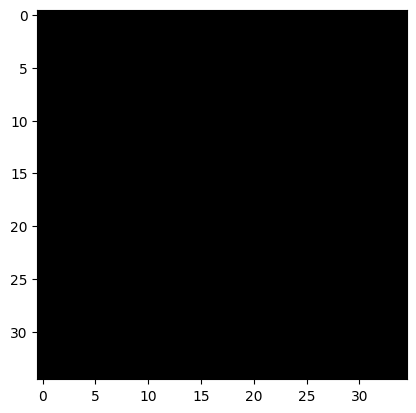

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]

loss: 10005.06640625, epoch:222/1000


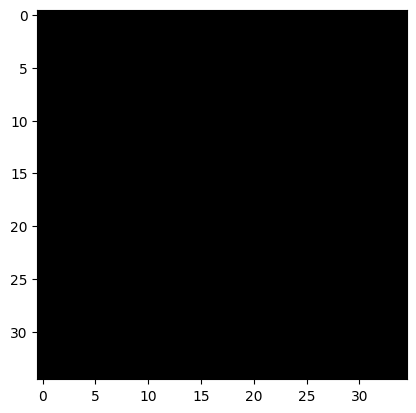

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9679.01953125, epoch:223/1000


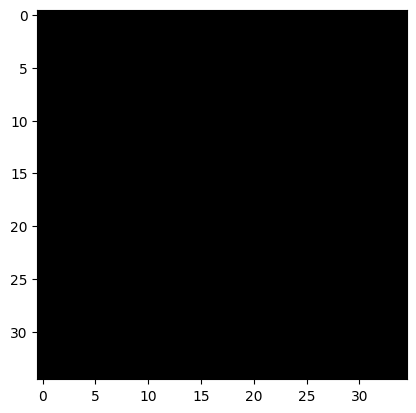

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9427.1396484375, epoch:224/1000


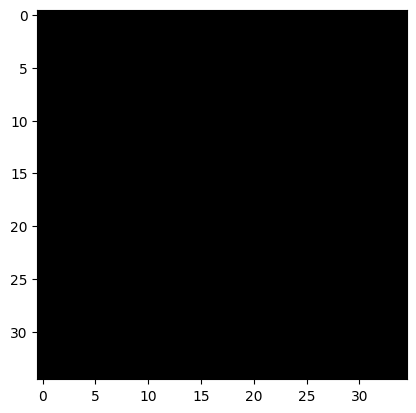

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10279.5400390625, epoch:225/1000


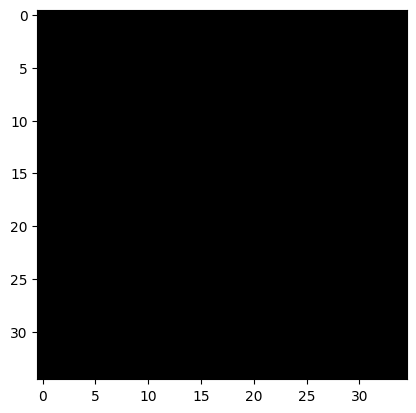

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9460.630859375, epoch:226/1000


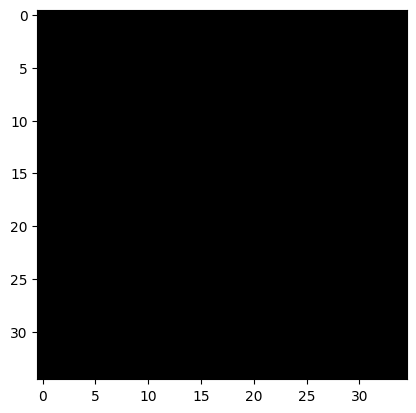

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9858.8330078125, epoch:227/1000


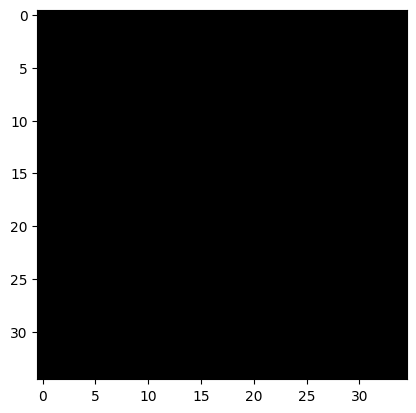

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9912.4697265625, epoch:228/1000


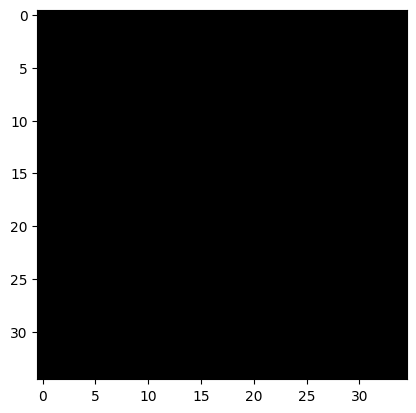

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9621.216796875, epoch:229/1000


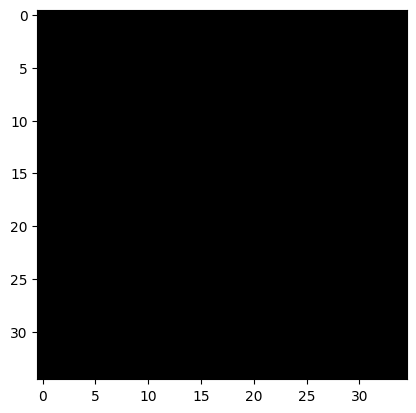

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9719.47265625, epoch:230/1000


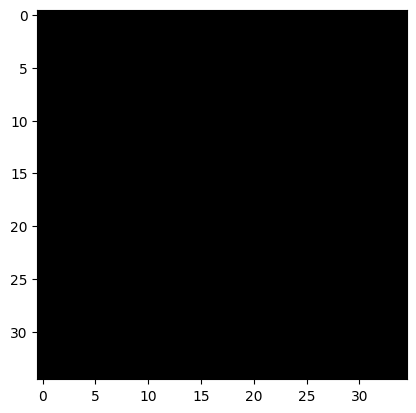

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9376.2939453125, epoch:231/1000


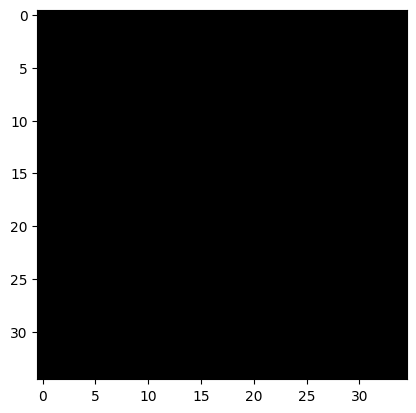

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9420.3359375, epoch:232/1000


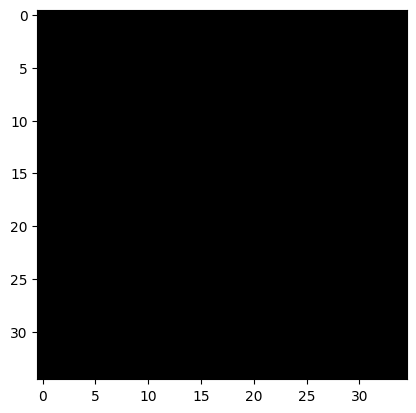

100%|██████████| 176/176 [01:01<00:00,  2.87it/s]


loss: 9774.6513671875, epoch:233/1000


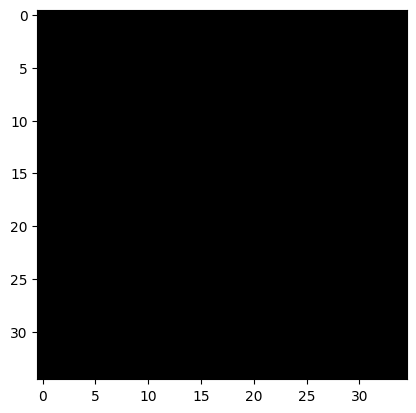

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10029.8359375, epoch:234/1000


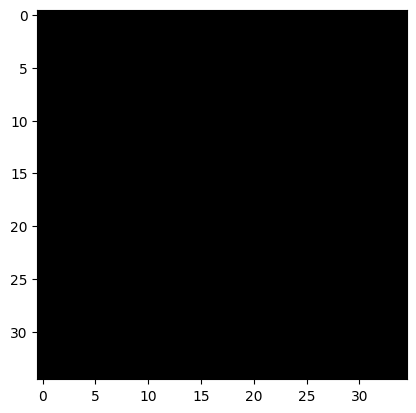

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10421.06640625, epoch:235/1000


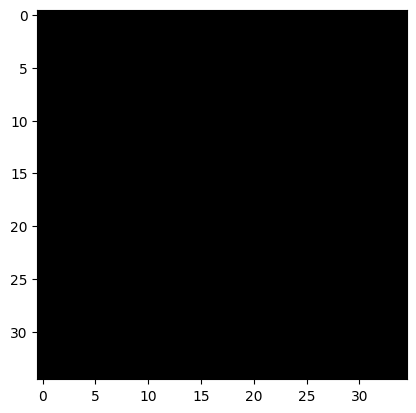

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]

loss: 9877.427734375, epoch:236/1000


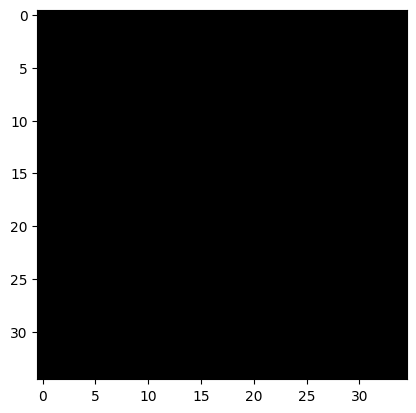

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9789.671875, epoch:237/1000


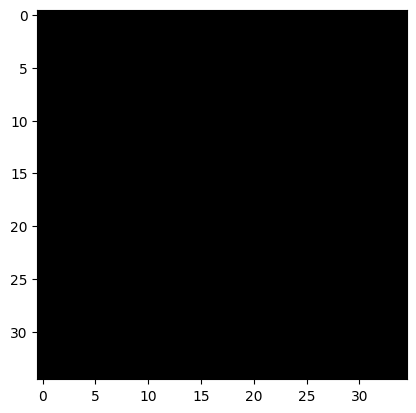

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 10135.158203125, epoch:238/1000


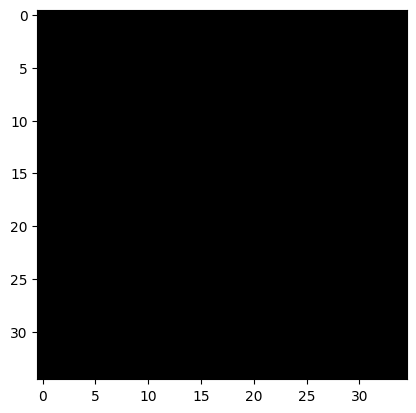

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]


loss: 10034.2734375, epoch:239/1000


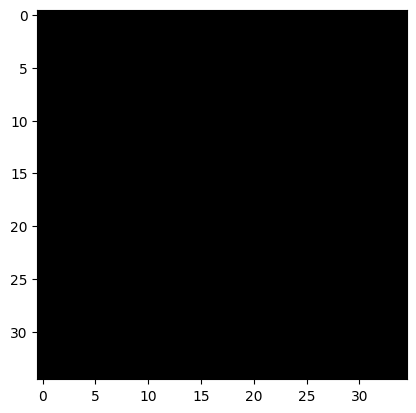

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9882.9482421875, epoch:240/1000


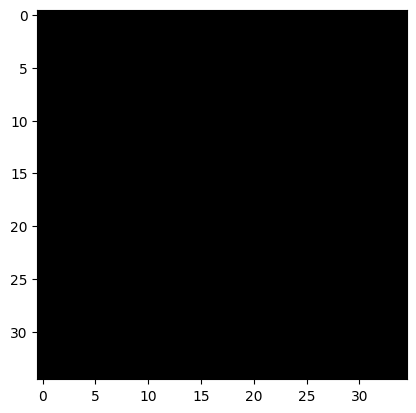

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]


loss: 10429.12890625, epoch:241/1000


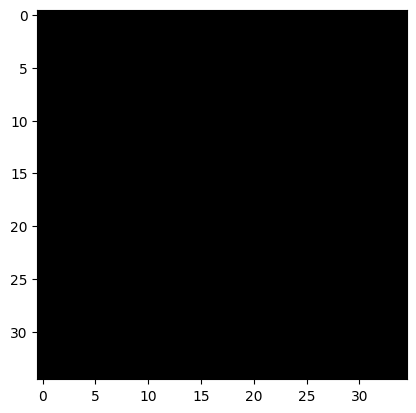

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9958.513671875, epoch:242/1000


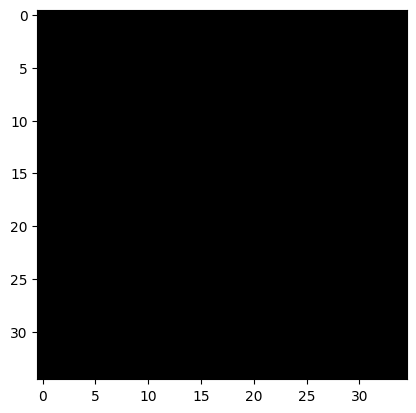

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 9816.564453125, epoch:243/1000


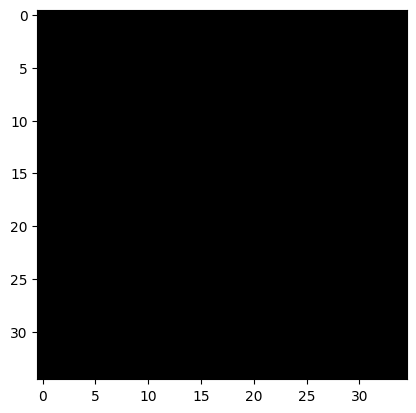

100%|██████████| 176/176 [01:03<00:00,  2.78it/s]


loss: 9839.0791015625, epoch:244/1000


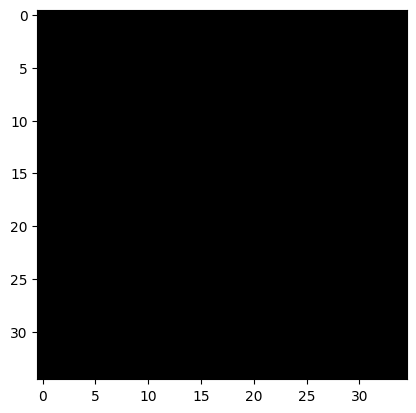

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10416.91015625, epoch:245/1000


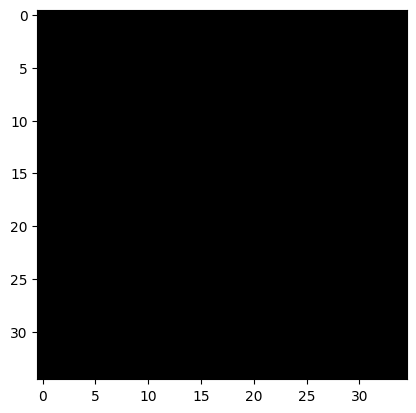

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]

loss: 10205.609375, epoch:246/1000


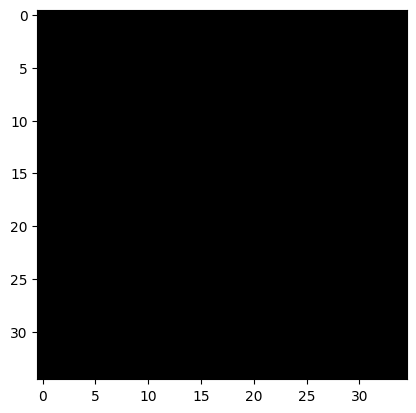

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 9793.826171875, epoch:247/1000


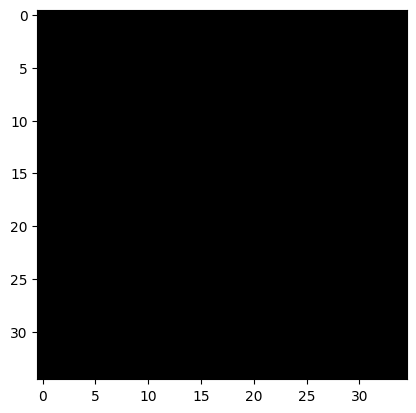

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10018.4091796875, epoch:248/1000


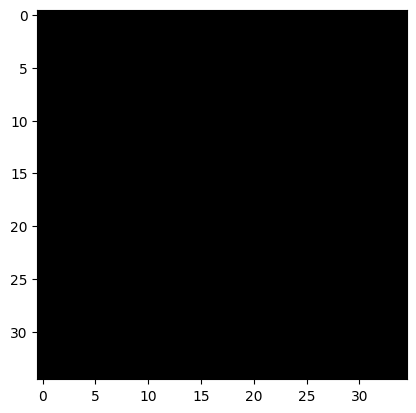

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9856.70703125, epoch:249/1000


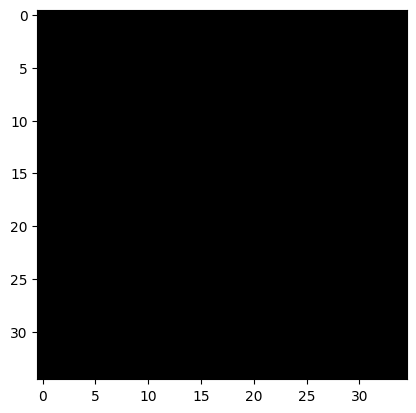

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 9391.515625, epoch:250/1000


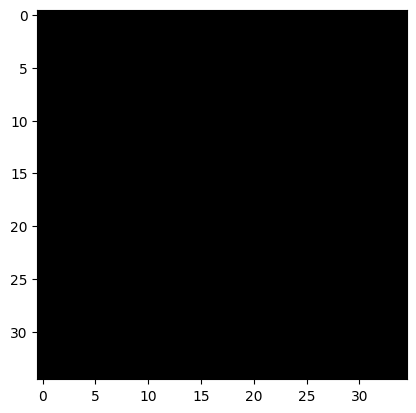

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9934.7978515625, epoch:251/1000


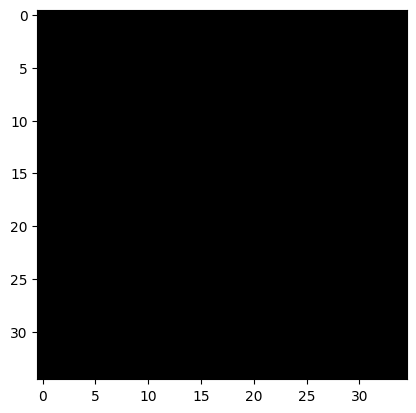

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9615.6123046875, epoch:252/1000


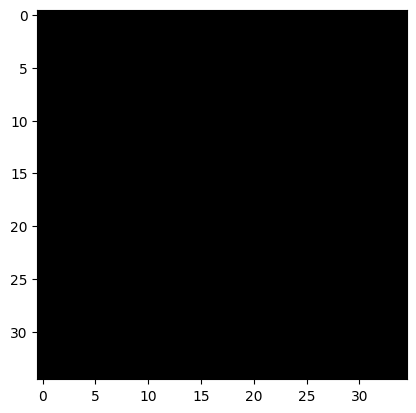

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9651.3916015625, epoch:253/1000


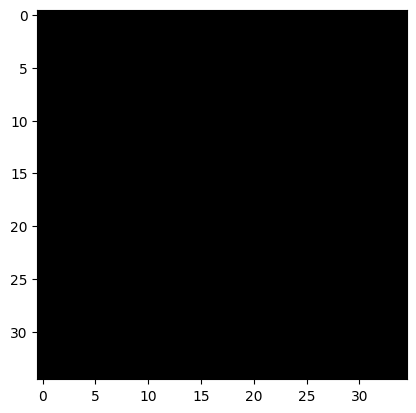

100%|██████████| 176/176 [01:02<00:00,  2.84it/s]


loss: 9940.8095703125, epoch:254/1000


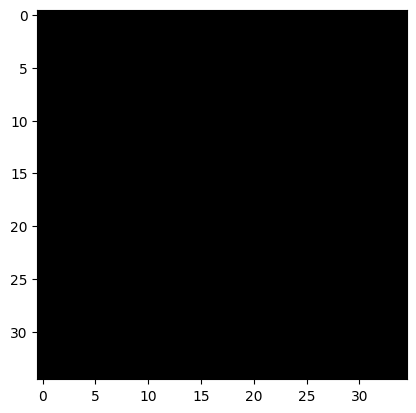

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]


loss: 10129.2314453125, epoch:255/1000


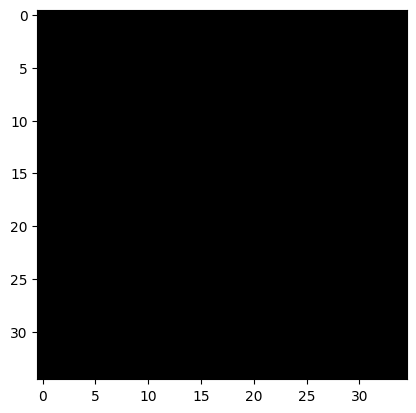

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9724.892578125, epoch:256/1000


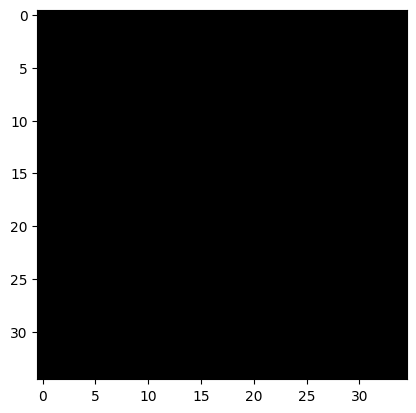

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9764.7138671875, epoch:257/1000


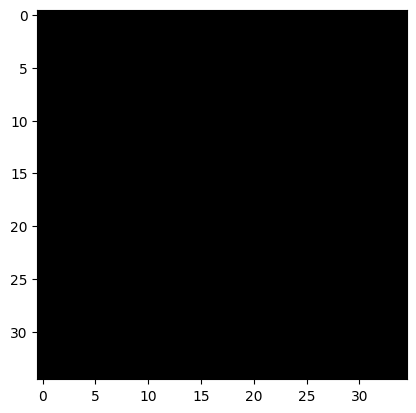

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]


loss: 9810.7294921875, epoch:258/1000


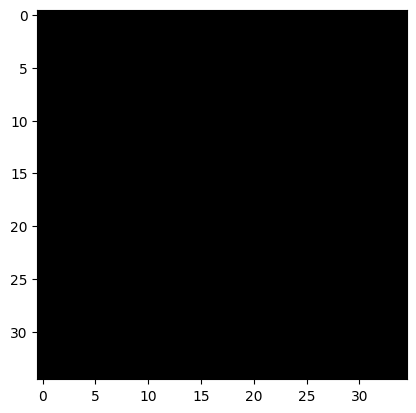

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 9606.3857421875, epoch:259/1000


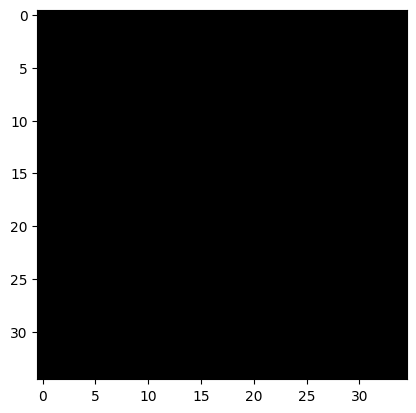

100%|██████████| 176/176 [01:01<00:00,  2.84it/s]

loss: 9513.7265625, epoch:260/1000


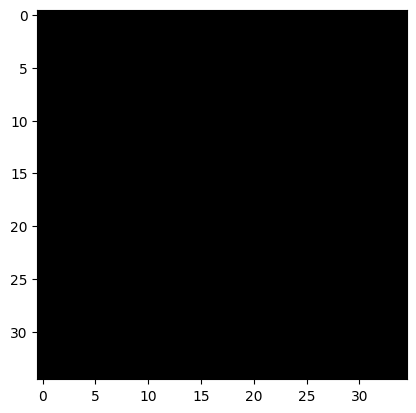

100%|██████████| 176/176 [01:01<00:00,  2.85it/s]

loss: 10243.95703125, epoch:261/1000


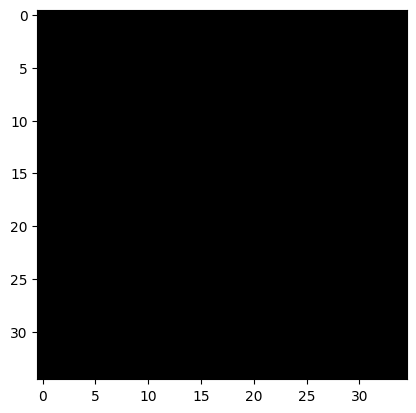

100%|██████████| 176/176 [01:01<00:00,  2.86it/s]

loss: 10011.701171875, epoch:262/1000


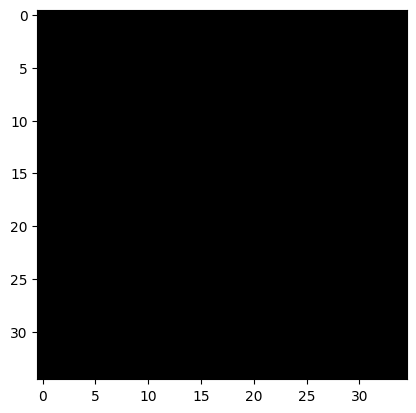

100%|██████████| 176/176 [01:02<00:00,  2.83it/s]


loss: 10036.712890625, epoch:263/1000


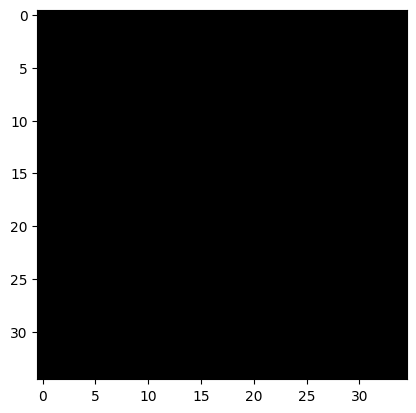

  3%|▎         | 5/176 [00:06<03:56,  1.39s/it]


KeyboardInterrupt: 

In [10]:
iteration=0
for epohc in range(num_epochs):
    closs=0
    for idx,batch in enumerate(tqdm.tqdm(train_dataloader)):
        model.train()
        images=transform(batch['image']).to(device)
        mask=transform(batch['mask'][:,1:,0,:]).to(device)
        optimizer.zero_grad()
        recon,rmask=model(images,get_masks=True)
        loss=critres(recon,images)+critmask(rmask,mask)
        loss.backward()
        optimizer.step()
        
        closs+=loss.detach()
        del loss,recon,images
    loss_evolution+=[closs/len(train_dataloader)]
    sched.step()
    print(f"loss: {closs}, epoch:{epohc}/{num_epochs}")
    ##
    model.eval()
    with torch.no_grad():
        plt.imshow(model(visual).detach().to('cpu')[0,:,:,:].permute(1,2,0))
        plt.show()
    ##
    if epohc%10==0:
        torch.save(model.state_dict(), model_dir+"/autosave.pt")
        with open(model_dir+'/stats.pkl', mode='wb') as file:
            pickle.dump(loss_evolution,file)

In [ ]:
torch.save(model.state_dict(), model_dir+"/final.pt")